#Chess graph analysis with SMA
*a.k.a the best project in this course*

## **contents**

1. Dependencies and network loading
2. Data management and network exploration
3. Network analysis (and custom algorithm)
4. Network visualization


In [ ]:
!pip install chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 29.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=a3947251603200435154cf2b9f9fd7baa18420371b4edc1d9bc52896ced15227
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


#Network loading

We first load a curated dataset from chess.com using the chess library to manage the specific chess-related dependencies such as the fed structure. We then performed a topological sort based on the number of visits and created an structure where the edge corresponds to it's hash ID, the edges as the direct link from one chess disposition to another. We also added relevant information over the nodes (fen: i.e., the chessboard pieces distribution; the total number of visits to this node, and the amount of outcomes resulting from this chess position <win, loss, draw>) and edges (probabilty of reaching this node, and overall count of games that have reached this game).




In [ ]:
#Graph loading using chess, son and NX
import networkx as nx
import json
import chess

#file_path = 'chess_graph_small.json'

file_path = "chess_graph_2015_05_6k.json"

with open(file_path, 'r') as file:
    raw_data = json.load(file)

# 2. Sort the data by 'total_visits' descending
# This ensures the starting position (most visits) is at index 0
sorted_items = sorted(
    raw_data.items(),
    key=lambda item: item[1].get('total_visits', 0),
    reverse=True
)

# Convert back to an ordered dictionary
ordered_data = dict(sorted_items)

# 3. Construct the Directed Graph
G = nx.DiGraph()

# Add nodes first to preserve the 'topological' visit-based order
for node_hash, node_info in ordered_data.items():
    G.add_node(node_hash,
               fen=node_info.get('fen'),
               visits=node_info.get('total_visits'),
               outcomes=node_info.get('outcomes'))

# Now add the edges
for node_hash, node_info in ordered_data.items():
    edges = node_info.get('edges', {})
    for next_hash, edge_data in edges.items():
        # We only add edges if the destination exists in our node list
        if G.has_node(next_hash):
            G.add_edge(node_hash, next_hash,
                       weight=edge_data['prob'],
                       count=edge_data['count'])

# 4. Verify the "First" Node
first_node_hash = list(ordered_data.keys())[0]
first_node_data = G.nodes[first_node_hash]

print(f"Total Nodes: {G.number_of_nodes()}")
print(f"First Node Hash: {first_node_hash}")
print(f"First Node Visits: {first_node_data['visits']}")
print(f"First Node FEN: {first_node_data['fen']}")

# Display the board of the first node
if first_node_data['fen']:
    print("\n--- Visual Confirmation of First Node ---")
    print(chess.Board(first_node_data['fen']))


#print(data["5060803636482931868"])

Total Nodes: 6196
First Node Hash: 5060803636482931868
First Node Visits: 960084
First Node FEN: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1

--- Visual Confirmation of First Node ---
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R


In [ ]:
"""
THE STRUCTURE OF A NODE IN OUR GRAPH
Node: "hash": pointer to next Nod
ID: {
  edges: [hash + probability + count]
  outcomes: Win Draw Loss from that position
  total visits: frequency of games where this position was played
  fen: structure of the chess board <positions current player <w,b>, castleing rules - "turn">
}
"""

'\nTHE STRUCTURE OF A NODE IN OUR GRAPH\nNode: "hash": pointer to next Nod\nID: {\n  edges: [hash + probability + count]\n  outcomes: Win Draw Loss from that position\n  total visits: frequency of games where this position was played\n  fen: structure of the chess board <positions current player <w,b>, castleing rules - "turn">\n}\n'

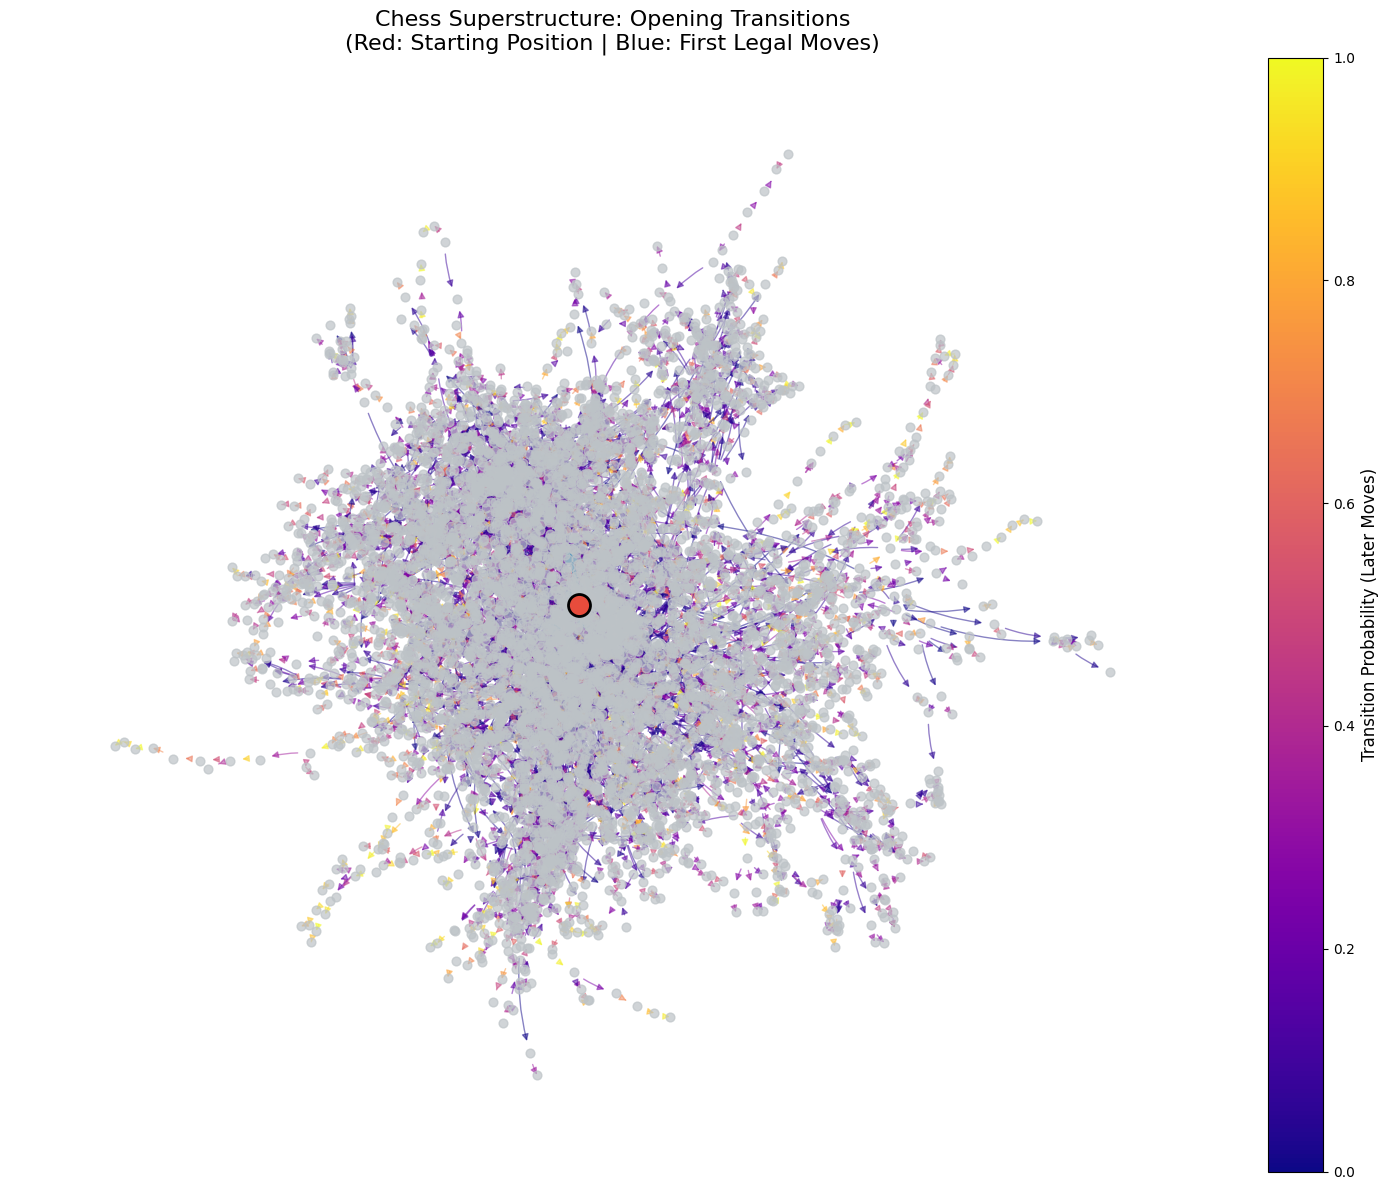

In [ ]:
#Let's look at your cool supergraph guys.
import matplotlib.pyplot as plt
import networkx as nx

# We Filter the graph (Top 300 most visited nodes)
TOP_N = 6000
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
core_nodes = [n[0] for n in sorted_nodes[:TOP_N]]
core_G = G.subgraph(core_nodes)

# We know the first node is the one with the most visits. I want to color it in red for explainability
first_node_hash = core_nodes[0]

plt.figure(figsize=(14, 12))

# layout
pos = nx.spring_layout(core_G, k=0.3, iterations=50)

# All the other nodes and edges

# Separate nodes and edges
other_nodes = [node for node in core_G.nodes() if node != first_node_hash]
other_edges = [(u, v) for u, v in core_G.edges() if u != first_node_hash]

# Draw standard nodes
nx.draw_networkx_nodes(core_G, pos,
                       nodelist=other_nodes,
                       node_size=40,
                       node_color='#bdc3c7',
                       alpha=0.7)

# Draw standard edges (probability colormap)
other_edge_probs = [core_G[u][v].get('weight', 0.0) for u, v in other_edges]
nx.draw_networkx_edges(
    core_G, pos,
    edgelist=other_edges,
    edge_color=other_edge_probs,
    edge_cmap=plt.cm.plasma,
    width=1.0,
    alpha=0.5, # Slightly transparent to let the root edges pop
    arrowsize=10,
    connectionstyle="arc3,rad=0.1"
)

# Now I want to draw the first node and it's connections (second moves)

# Draw the starting node (larger, red, with a border)
nx.draw_networkx_nodes(core_G, pos,
                       nodelist=[first_node_hash],
                       node_size=250, # Significantly larger
                       node_color='#e74c3c', # A clean, professional red
                       edgecolors='black',
                       linewidths=2,
                       alpha=1.0)

# Draw direct connections from the start node (thicker, solid blue)
direct_edges = [(u, v) for u, v in core_G.edges() if u == first_node_hash]
nx.draw_networkx_edges(
    core_G, pos,
    edgelist=direct_edges,
    edge_color='#2980b9', # A sharp, structural blue
    width=3.0, # Thicker lines to show primary pathways
    alpha=1.0,
    arrowsize=15,
    connectionstyle="arc3,rad=0.1"
)

# A little makeup so it looks nice
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label('Transition Probability (Later Moves)', fontsize=12)

plt.title(f'Chess Superstructure: Opening Transitions\n(Red: Starting Position | Blue: First Legal Moves)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Data management polish and network exploration

In order to implement a graph analysis technique that will provide a meaningful result to our specific field of research we propose to perform an Outcome-weighted path scoring by using a modified Depth-limited depth first search algorithm as it is one of the most significant information difussion techniques.

$$E[v] = \frac{W_v - L_v}{W_v + L_v + D_v}$$

Nothing to particulary crazy: since we have the counts for each node and remember college-level statistics, we can create the Expected value, as a likelihood value of winning or loosing given all the possible values.

The usage of a custom expected value function based on the current node counts (i.e., overall count of wining, losing, or drawing based on the current position) was suggested following equation 1, it's purpose is to provide a normalized metric with which to enrich a DFS algorithm based on the combination of the next step node to go from the current position considering both the associated probability and the Expected value of the selecting this node.

## Network exploration

1. **Network density**: Density measures how conected is a graph from 0 to 1; if we have a dense graph (several nodes connected or completed) it will reach 1, we obviusly need to check this goes near zero if we're playing smart chess (low density = smart players since their movements are not exactly random)

2. **Page Rank**:  PageRank is the algorithm Mourad told us from Google to rank the web pages. Why does it matter here? because it measures the "transitive importance" (relevant + connected to other relevant nodes), translated to our game this measures **transpositons** how famous a node is meaning how many paths lead to this node.

3. **Betweeness centrality**: BC is the metric to measure who are the "bridges" or "bottlenecks" in our graph. In chess this will mean the points of no return.

4. **Out degree centrality**: We care for the nodes with the most possible moves to go out from, the nodes with the most branches.


We used Density to validate the sparse, sequential nature of the game. We used PageRank to find unavoidable transpositional hubs, Betweenness to identify the structural bottlenecks bridging the opening and mid-game, and Out-Degree Centrality to map the nodes with the highest tactical complexity."

Since my autism knows no limits, I created this beautiful graph visualization for the metrics along with the visualization for the Expected value ;)




In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities
import numpy as np

# Calculate and store Expected Value (E[v]) for every node
for node in G.nodes():
    # Outcomes: [Win, Draw, Loss]
    outcomes = G.nodes[node].get('outcomes', [0, 0, 0])
    if outcomes is None: outcomes = [0, 0, 0]

    W, L, D = outcomes[0], outcomes[1], outcomes[2] #Win , loss, draw
    total = W + D + L

    if total > 0:
        G.nodes[node]['expected_value'] = (W - L) / total
    else:
        G.nodes[node]['expected_value'] = 0.0

"""
NETWORK EXPLORATION
"""
# Structural properties
print(f"Network Density: {nx.density(G):.5f}")

# Centrality: PageRank identifies 'hub' chess states that games frequently funnel through
pagerank = nx.pagerank(G, weight='weight')
top_pagerank_node = max(pagerank, key=pagerank.get)
betweenness = nx.betweenness_centrality(core_G)
top_bc = max(betweenness, key=betweenness.get)

print(f"\n--- Network Centrality Metrics ---")
print(f"Node with highest PageRank (Most Central State): {top_pagerank_node}")
print(f"Highest PageRank Score: {pagerank[top_pagerank_node]:.5f}")
print(f"Betweenesss centrality score: {top_bc}")

Network Density: 0.00023

--- Network Centrality Metrics ---
Node with highest PageRank (Most Central State): 4918247330996767761
Highest PageRank Score: 0.00250
Betweenesss centrality score: 8704797333742910878


I added a cool visualization for the Expected value accross nodes and the pageRank score

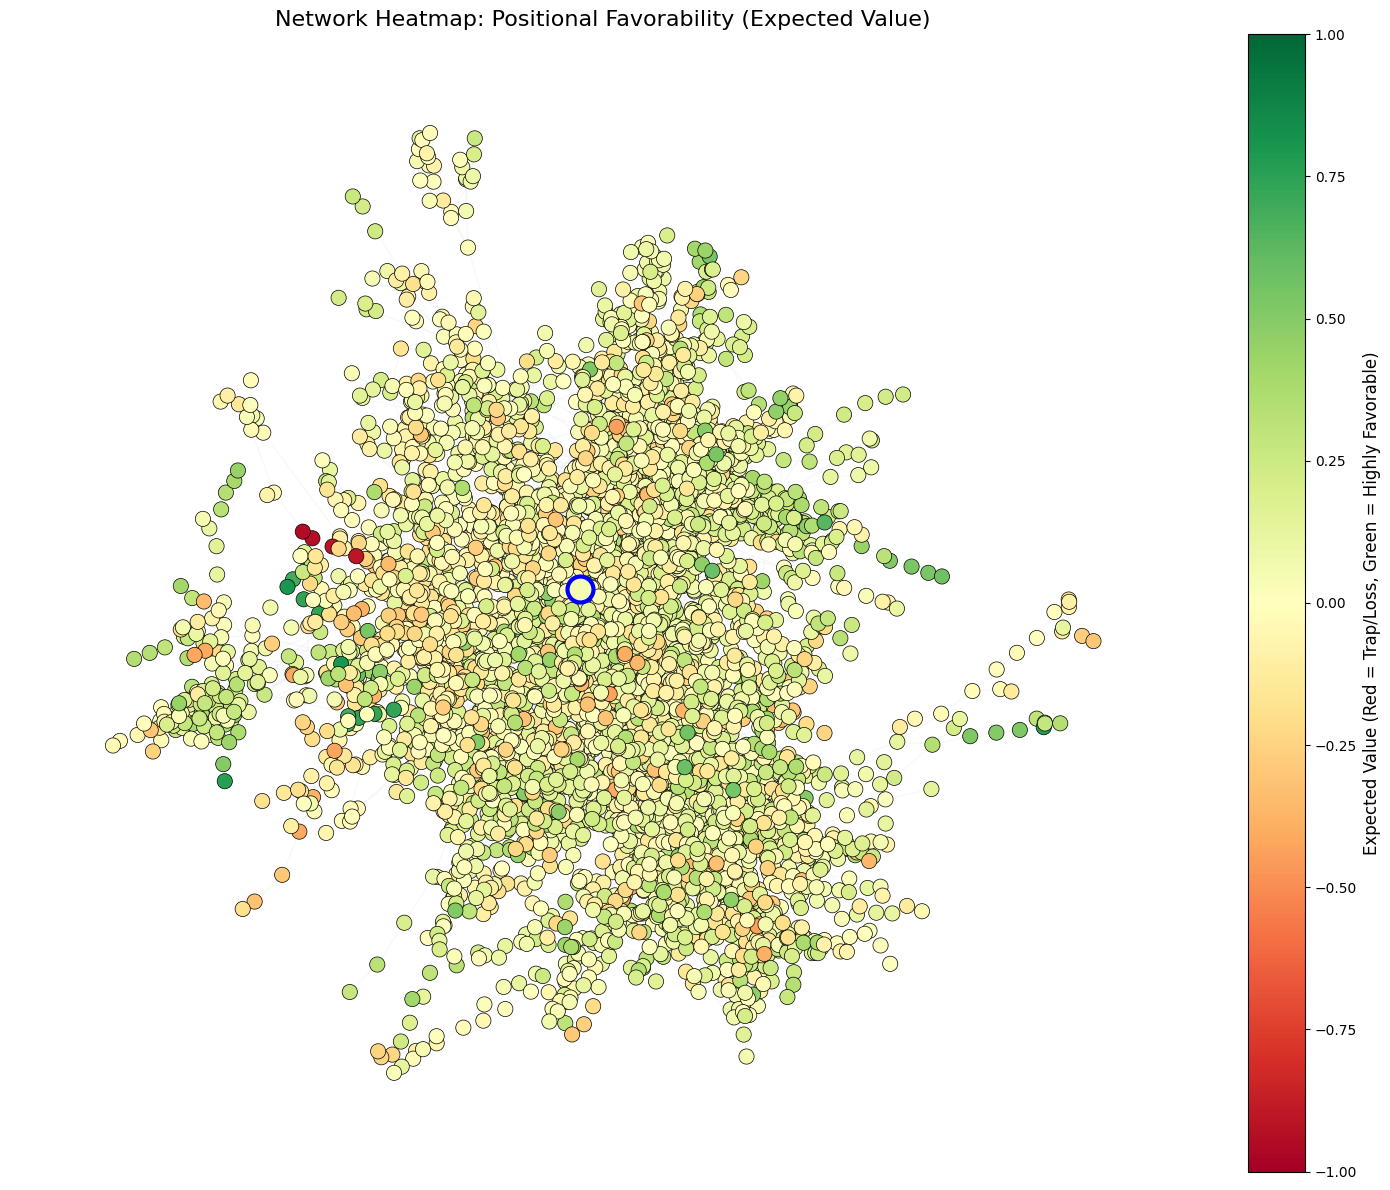

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# expected value heatmap
# 1. Extract the Core Network
TOP_N = 6000
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
core_nodes = [n[0] for n in sorted_nodes[:TOP_N]]
core_G = G.subgraph(core_nodes)

pos = nx.spring_layout(core_G, k=0.3, iterations=50)

# 3. Extract EVs for color mapping
node_evs = [core_G.nodes[n].get('expected_value', 0.0) for n in core_G.nodes()]

plt.figure(figsize=(14, 12))

nx.draw_networkx_edges(core_G, pos,
                       edge_color='#ecf0f1',
                       alpha=0.4,
                       width=1.0,
                       arrows=False)

nodes_plot = nx.draw_networkx_nodes(
    core_G, pos,
    node_size=120,
    node_color=node_evs,
    cmap=plt.cm.RdYlGn, # Red (Loss) -> Yellow (Draw/Eq) -> Green (Win)
    vmin=-1.0, # Minimum possible EV
    vmax=1.0,  # Maximum possible EV
    edgecolors='black',
    linewidths=0.5
)

# 6. Highlight the Starting Node (Thick blue border)
first_node_hash = core_nodes[0]
nx.draw_networkx_nodes(
    core_G, pos,
    nodelist=[first_node_hash],
    node_size=350,
    node_color=[core_G.nodes[first_node_hash].get('expected_value', 0.0)],
    cmap=plt.cm.RdYlGn,
    vmin=-1.0,
    vmax=1.0,
    edgecolors='#0000ff', # Blue highlight for the root
    linewidths=3
)

# 7. Add Colorbar & Polish
cbar = plt.colorbar(nodes_plot, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label('Expected Value (Red = Trap/Loss, Green = Highly Favorable)', fontsize=12)

plt.title('Network Heatmap: Positional Favorability (Expected Value)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

Calculating Centrality Metrics...


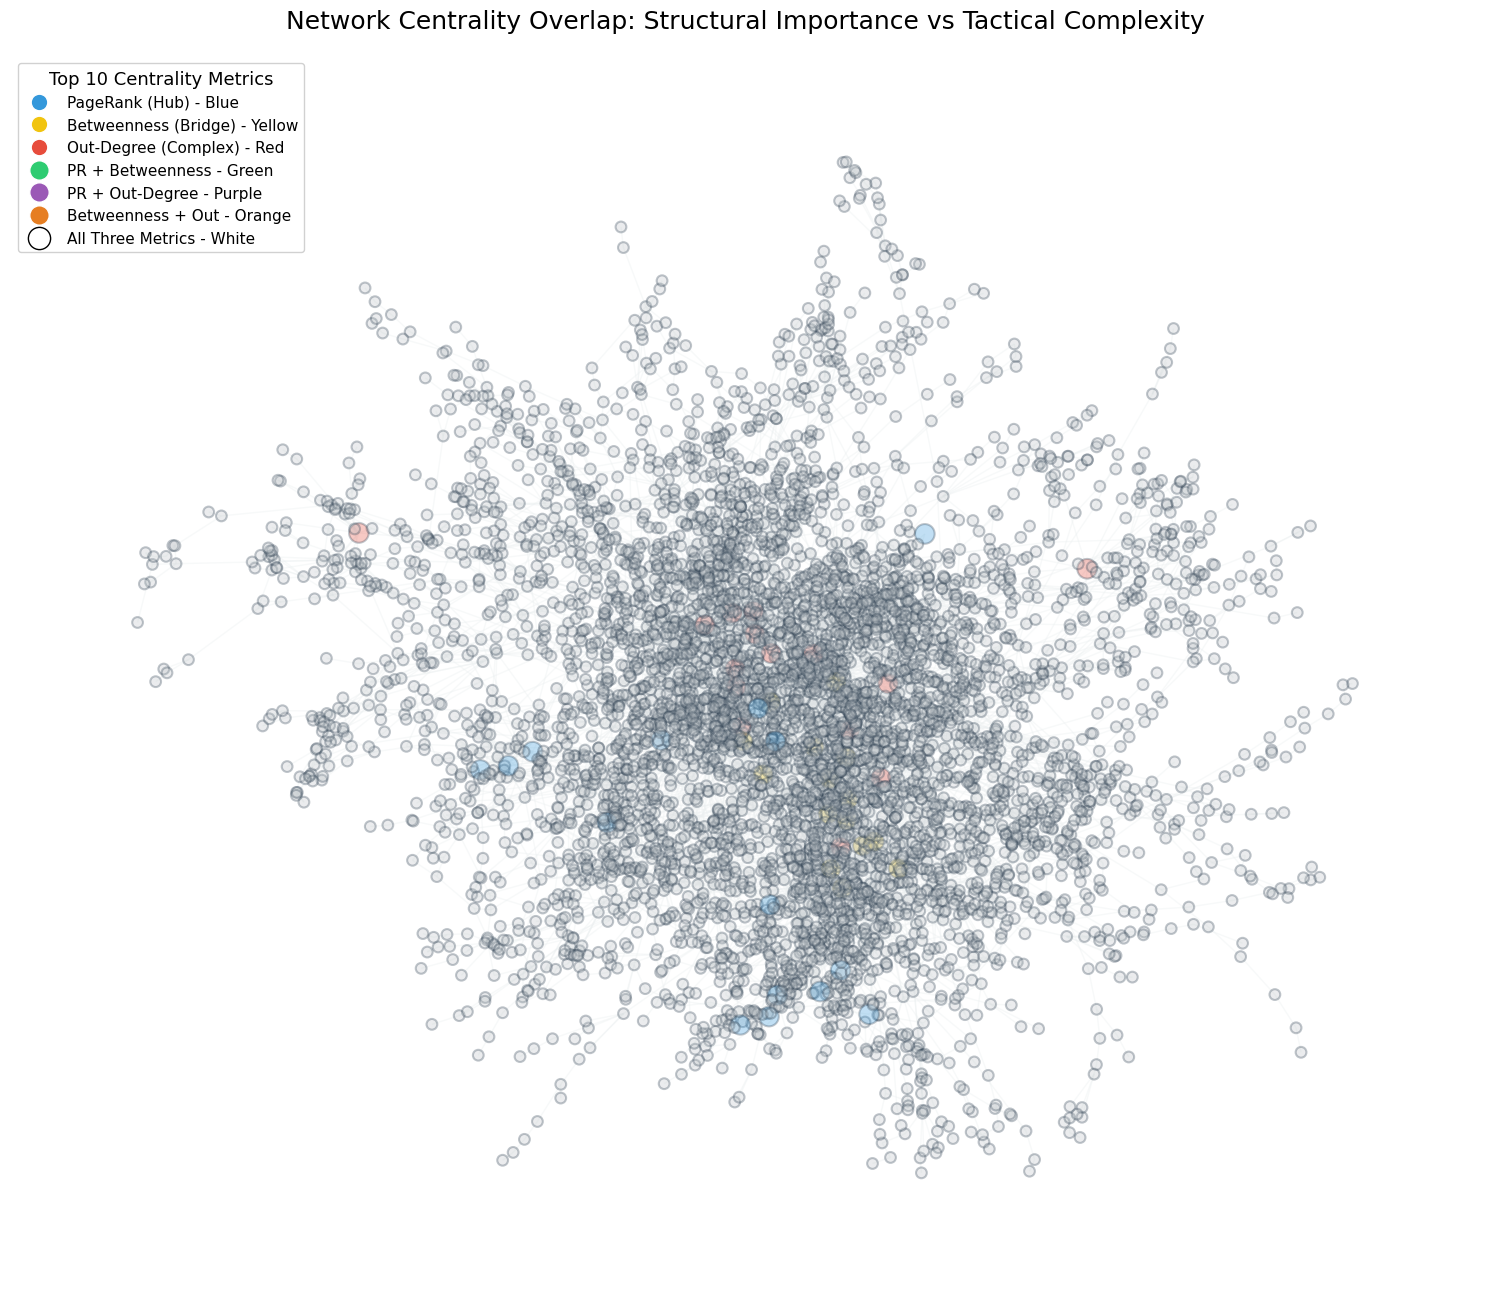

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

# Centrality overlap visualization
# 1. Filter Graph
TOP_N = 6000
amount_2_draw = 15
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
core_nodes = [n[0] for n in sorted_nodes[:TOP_N]]
core_G = G.subgraph(core_nodes)
alpha = False
# 2. Compute the Metrics strictly on our visual Core Graph
print("Calculating Centrality Metrics...")

# PageRank (Blue)
pagerank = nx.pagerank(core_G, weight='weight')
top_pr = set(sorted(pagerank, key=pagerank.get, reverse=True)[:amount_2_draw])

# Betweenness (Yellow)
betweenness = nx.betweenness_centrality(core_G)
top_bet = set(sorted(betweenness, key=betweenness.get, reverse=True)[:amount_2_draw])

# Out-Degree (Red)
out_degree = dict(core_G.out_degree())
top_out = set(sorted(out_degree, key=out_degree.get, reverse=True)[:amount_2_draw])

# 3. Apply the Color Mixing Logic
node_colors = []
node_sizes = []

for node in core_G.nodes():
    in_pr = node in top_pr
    in_bet = node in top_bet
    in_out = node in top_out

    # Check overlaps first (The Venn Diagram logic)
    if in_pr and in_bet and in_out:
        color = '#0031e2' # White (All three)
        size = 500
    elif in_pr and in_bet:
        color = '#2ecc71' # Green (Blue + Yellow)
        size = 350
    elif in_pr and in_out:
        color = '#9b59b6' # Purple (Blue + Red)
        size = 350
    elif in_bet and in_out:
        color = '#e67e22' # Orange (Yellow + Red)
        size = 350
    elif in_pr:
        color = '#3498db' # Blue
        size = 200
    elif in_bet:
        color = '#f1c40f' # Yellow
        size = 200
    elif in_out:
        color = '#e74c3c' # Red
        size = 200
    else:
        color = '#bdc3c7' # Light Gray
        size = 60
        alpha = True

    node_colors.append(color)
    node_sizes.append(size)

plt.figure(figsize=(15, 13))
pos = nx.spring_layout(core_G, k=0.35, iterations=50)

nx.draw_networkx_edges(core_G, pos, edge_color='#ecf0f1', alpha=0.4, width=1.0, arrows=False)

if alpha:
  nx.draw_networkx_nodes(core_G, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       edgecolors='#2c3e50', # Dark border to make white/yellow pop
                       linewidths=1.5, alpha=0.3)
  alpha = False
else:
  nx.draw_networkx_nodes(core_G, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       edgecolors='#2c3e50', # Dark border to make white/yellow pop
                       linewidths=1.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='PageRank (Hub) - Blue', markerfacecolor='#3498db', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Betweenness (Bridge) - Yellow', markerfacecolor='#f1c40f', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Out-Degree (Complex) - Red', markerfacecolor='#e74c3c', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='PR + Betweenness - Green', markerfacecolor='#2ecc71', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='PR + Out-Degree - Purple', markerfacecolor='#9b59b6', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='Betweenness + Out - Orange', markerfacecolor='#e67e22', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='All Three Metrics - White', markerfacecolor='#ffffff', markeredgecolor='black', markersize=16),
]

plt.legend(handles=legend_elements, loc='upper left', title="Top 10 Centrality Metrics",
           fontsize=11, title_fontsize=13, framealpha=0.9)

plt.title('Network Centrality Overlap: Structural Importance vs Tactical Complexity', fontsize=18, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Network analysis

In order to make some nice analysis I'm proposing two different techniques: clusterization and our modified DFS. Since a very important part of our grade is the implementation of the DFS on our own I will describe it with excruciating detail.

## Cluster finding (community detection)

Greedy modularity is the way to go with this, the reasoning behind it? it is perfect to find clusters of "game states"

## Modified Depth-limited depth first search

The custom algorithm explained in pseudo-code can be told as a recursive algorithm that follows:

1. Select a node v
2. if the current depth is the limit of our search, or there is no more paths to explore, we finish the search.
3. (recursive) if v has out-degree (successors), for each node u:
  - extract the child probabilty and expected value
  - calculate the probality * expected value
  - perform next step





In [ ]:
"""
Network analysis
"""
# Community Detection (Using built-in library)
# Convert to undirected temporarily for community detection
undirected_G = G.to_undirected()
# Using greedy modularity to find clusters of game states
communities = list(greedy_modularity_communities(undirected_G))
print(f"\nDetected {len(communities)} distinct communities (clusters of game states).")


# Custom Algorithm: Outcome-Weighted Path Scoring (From Scratch)
def get_top_weighted_paths(graph, start_node, depth_limit=4, top_k=5):
    """
    Custom Depth-Limited DFS to find the highest-scoring tactical paths.
    Does not use external pathfinding libraries.
    """
    valid_paths = []

    def custom_dfs(current_node, current_path, current_score, current_depth):
        # Base case: reached depth limit or a leaf node (checkmate/draw/end of data)
        if current_depth == depth_limit or graph.out_degree(current_node) == 0:
            valid_paths.append((current_path, current_score))
            return

        # Recursive case: explore successors
        for next_node in graph.successors(current_node):
            edge_prob = graph[current_node][next_node].get('weight', 0.0) #current edge probability
            child_ev = graph.nodes[next_node].get('expected_value', 0.0) #success of move given the future step/child

            # Heuristic calculation: Edge Probability * Expected Value of the outcome
            step_score = edge_prob * child_ev

            # Continue search deeper
            custom_dfs(next_node,
                       current_path + [next_node],
                       current_score + step_score,
                       current_depth + 1)

    # Initialize DFS from the starting node
    custom_dfs(start_node, [start_node], 0.0, 0)

    # Sort paths by score descending (from scratch sorting logic via lambda)
    valid_paths.sort(key=lambda x: x[1], reverse=True)

    return valid_paths[:top_k]

print("\n--- Running Custom Path Scoring Algorithm ---")
top_paths = get_top_weighted_paths(G, first_node_hash, depth_limit=4, top_k=3)

for i, (path, score) in enumerate(top_paths):
    print(f"Rank {i+1} Path Score: {score:.4f}")
    print(f"Path Nodes: {path}\n")


Detected 143 distinct communities (clusters of game states).

--- Running Custom Path Scoring Algorithm ---
Rank 1 Path Score: 0.3440
Path Nodes: ['5060803636482931868', '14562399549841627035', '5724685530517084605', '4708707909813669280', '14228104667444179050']

Rank 2 Path Score: 0.3239
Path Nodes: ['5060803636482931868', '14562399549841627035', '2570528886522758608', '1101940615639604712', '13832485817446159938']

Rank 3 Path Score: 0.2864
Path Nodes: ['5060803636482931868', '11339917551484771745', '17741424950250842682', '15767252650957206018', '7656330726474866073']



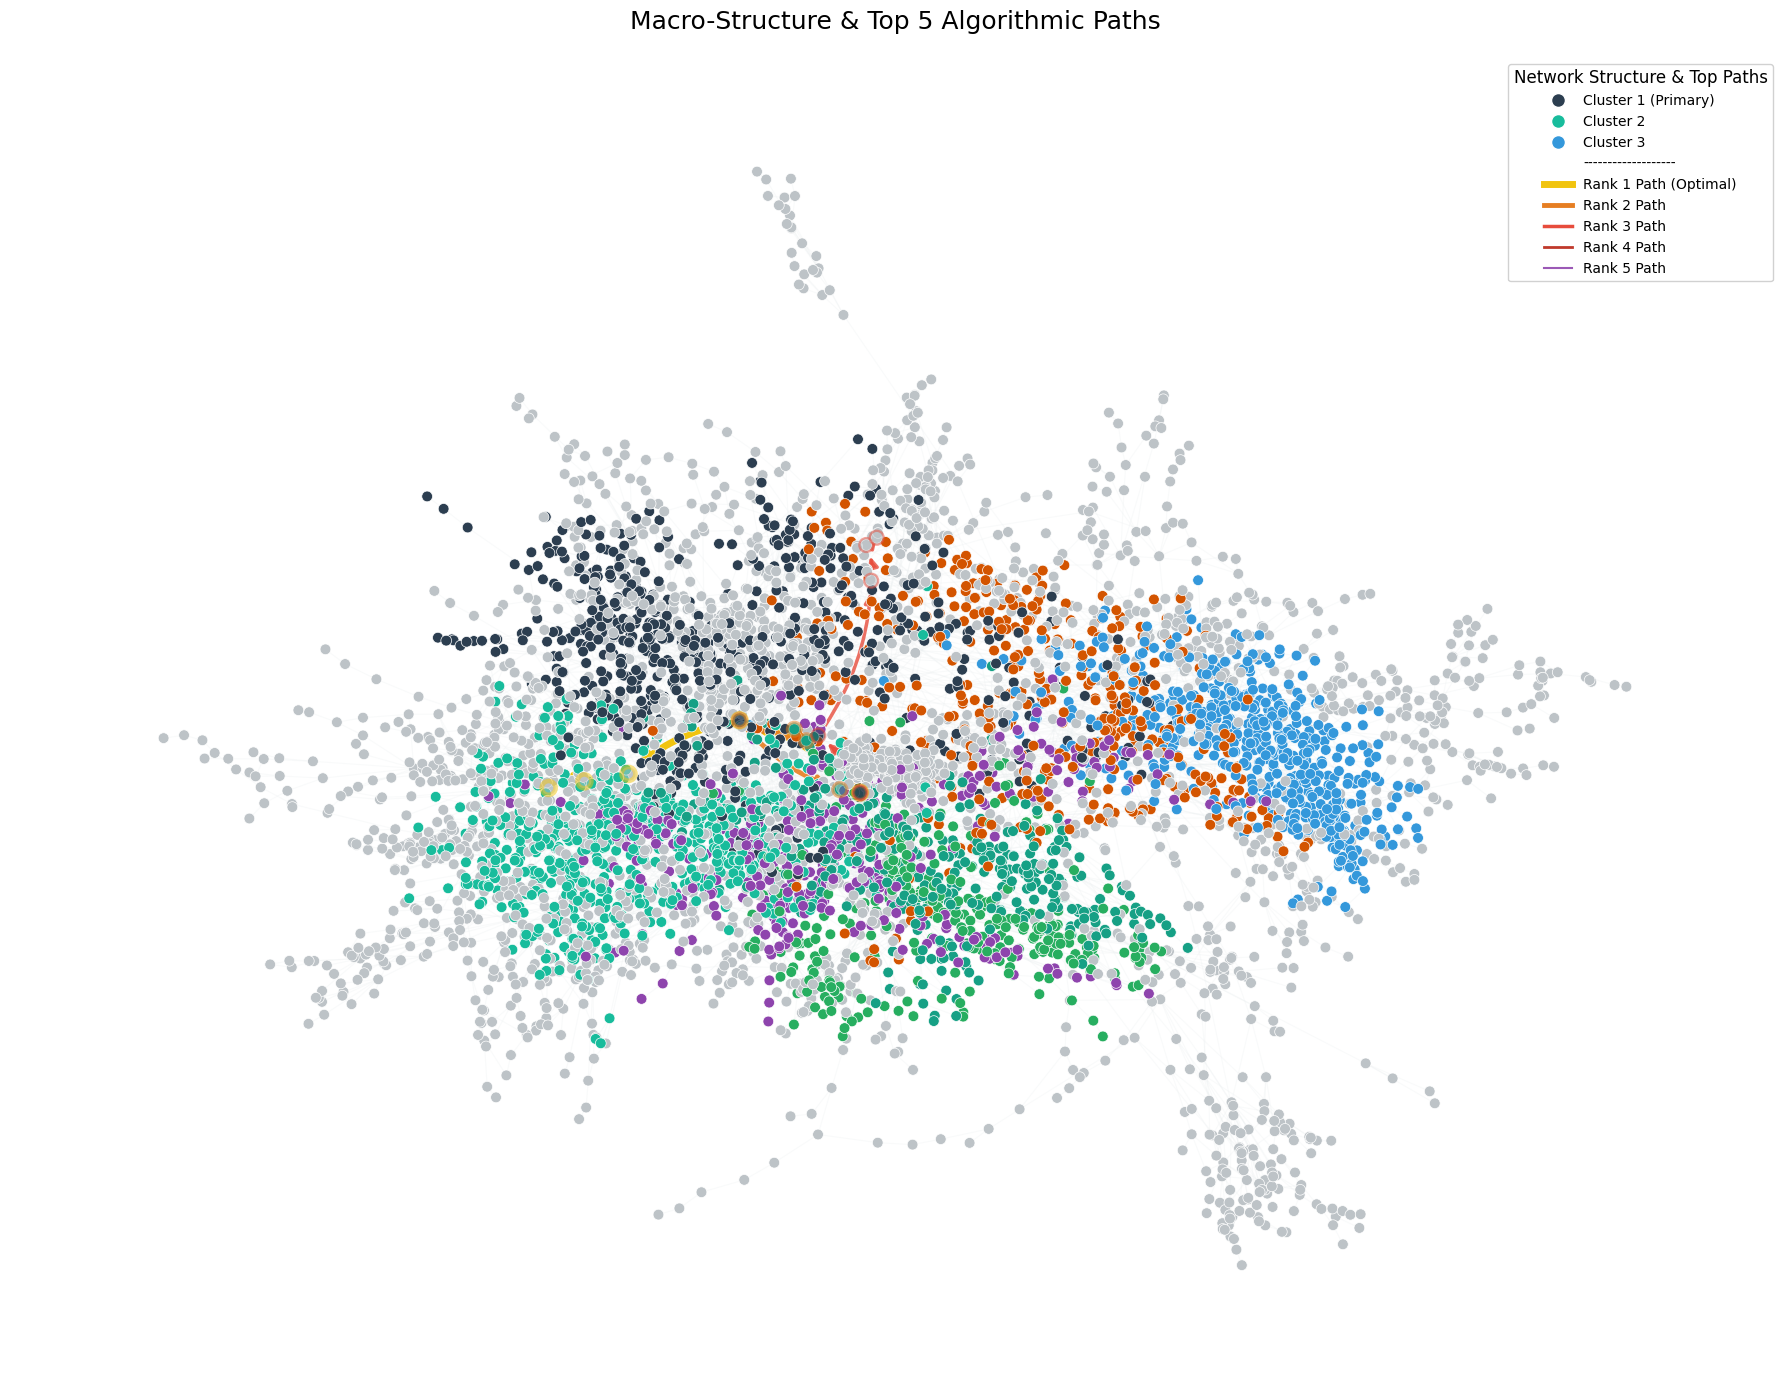

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
from matplotlib.lines import Line2D

TOP_N = 6000
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
core_nodes = [n[0] for n in sorted_nodes[:TOP_N]]
core_G = G.subgraph(core_nodes)

# 2. Community Detection
undirected_core = core_G.to_undirected()
communities = list(greedy_modularity_communities(undirected_core))

community_colors = ['#2c3e50', '#18bc9c', '#3498db', '#8e44ad', '#d35400', '#16a085', '#27ae60']
node_color_map = {}

for i, comm in enumerate(communities):
    color = community_colors[i] if i < len(community_colors) else '#bdc3c7'
    for node in comm:
        if node in core_G:
            node_color_map[node] = color

node_colors = [node_color_map.get(n, '#bdc3c7') for n in core_G.nodes()]
node_sizes = [200 if n == first_node_hash else 60 for n in core_G.nodes()]

plt.figure(figsize=(18, 14)) # Slightly larger canvas
pos = nx.spring_layout(core_G, k=0.15, iterations=60, seed=42) # k=0.25 spreads the expanded clusters out nicely

# Draw standard edges and nodes
nx.draw_networkx_edges(core_G, pos, edge_color='#ecf0f1', alpha=0.3, width=0.8, arrows=False)
nx.draw_networkx_nodes(core_G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='#ffffff', linewidths=0.5)

# We create a gradient style for the paths: Gold (Rank 1) -> Purple (Rank 5)
path_colors = ['#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#9b59b6']
path_widths = [5.0, 3.5, 2.5, 2.0, 1.5]
path_alphas = [1.0, 0.9, 0.8, 0.7, 0.6]

for rank in range(min(5, len(top_paths))):
    path_nodes = top_paths[rank][0]
    path_edges = [(path_nodes[i], path_nodes[i+1]) for i in range(len(path_nodes)-1)]

    drawable_edges = [(u, v) for u, v in path_edges if u in core_G and v in core_G]
    drawable_nodes = [n for n in path_nodes if n in core_G]

    # Highlight Path Nodes
    nx.draw_networkx_nodes(core_G, pos, nodelist=drawable_nodes, node_size=100,
                           node_color=[node_color_map.get(n) for n in drawable_nodes],
                           edgecolors=path_colors[rank], linewidths=path_widths[rank]/1.5, alpha=0.5)

    # Highlight Path Edges
    nx.draw_networkx_edges(core_G, pos, edgelist=drawable_edges, edge_color=path_colors[rank],
                           width=path_widths[rank], alpha=path_alphas[rank],
                           arrowsize=15, connectionstyle="arc3,rad=0.15")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Cluster 1 (Primary)', markerfacecolor=community_colors[0], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 2', markerfacecolor=community_colors[1], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 3', markerfacecolor=community_colors[2], markersize=10),
    Line2D([0], [0], color='w', label='-------------------'),
    Line2D([0], [0], color=path_colors[0], lw=5, label='Rank 1 Path (Optimal)'),
    Line2D([0], [0], color=path_colors[1], lw=3.5, label='Rank 2 Path'),
    Line2D([0], [0], color=path_colors[2], lw=2.5, label='Rank 3 Path'),
    Line2D([0], [0], color=path_colors[3], lw=2, label='Rank 4 Path'),
    Line2D([0], [0], color=path_colors[4], lw=1.5, label='Rank 5 Path'),
]

plt.legend(handles=legend_elements, loc='upper right', title="Network Structure & Top Paths",
           fontsize=10, title_fontsize=12, framealpha=0.9)

plt.title('Macro-Structure & Top 5 Algorithmic Paths', fontsize=18, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Final surprise: Regression

Our DFS is cool and everything, but you can't really use it in a real game since it is too computationally heavy (all the tests I did tonight are only with 300 nodes (It will be your computer's task to get toasted to check how this looks with all nodes involved)

To use ML to find the best outcomes is exactly the regression Bela suggested as a lovely outcome. So I build a not-so-fancy approach to it: A vanilla random forest.



In [ ]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Feature Extraction Function
def extract_path_features(graph, path):
    """Converts a path into a ML vector."""
    edge_probs = []
    node_evs = []
    out_degrees = []

    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_probs.append(graph[u][v].get('weight', 0.0))
        node_evs.append(graph.nodes[v].get('expected_value', 0.0))
        out_degrees.append(graph.out_degree(v))

    return {
        'path_length': len(path),
        'avg_edge_prob': np.mean(edge_probs) if edge_probs else 0,
        'min_edge_prob': np.min(edge_probs) if edge_probs else 0, # Bottlenecks or bridges
        'avg_expected_value': np.mean(node_evs) if node_evs else 0,
        'terminal_node_ev': node_evs[-1] if node_evs else 0,
        'avg_out_degree': np.mean(out_degrees) if out_degrees else 0
    }

# 2. Generate a Training Dataset via Random Walks
training_data = []

# 1000 random walks starting from highly visited nodes
walk_starts = [n for n, d in sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:50]]

for start_node in walk_starts:
    for _ in range(20): # 20 walks per start node
        current_node = start_node
        path = [current_node]
        path_score = 0.0

        for _ in range(5):
            successors = list(G.successors(current_node))
            if not successors:
                break

            next_node = random.choice(successors)

            # score (Our Target Variable 'y')
            step_prob = G[current_node][next_node].get('weight', 0.0)
            step_ev = G.nodes[next_node].get('expected_value', 0.0)
            path_score += (step_prob * step_ev)

            path.append(next_node)
            current_node = next_node

        if len(path) > 2: # Only keep meaningful paths
            features = extract_path_features(G, path)
            features['target_score'] = path_score
            training_data.append(features)

df = pd.DataFrame(training_data)

# 3. Train the Regression Model
print(f"Training Random Forest on {len(df)} paths...")
X = df.drop(columns=['target_score'])
y = df['target_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nModel Performance:")
print(f"R-squared Score: {r2:.4f} (How well topology predicts outcome)")
print(f"Root Mean Squared Error: {rmse:.4f}")

# Feature Importance
importances = model.feature_importances_
feature_names = X.columns
print("\nMost Critical Structural Features for Winning:")
for name, importance in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"- {name}: {importance:.3f}")

# Top 5 Algorithm Paths!
print("\nTesting ML Model against our Top 5 DFS Paths:")
for i, (path, actual_score) in enumerate(top_paths):
    path_features = pd.DataFrame([extract_path_features(G, path)])
    predicted_score = model.predict(path_features)[0]
    print(f"Rank {i+1} Path | Math Score: {actual_score:.4f} | ML Predicted Score: {predicted_score:.4f}")

Training Random Forest on 935 paths...

Model Performance:
R-squared Score: 0.9621 (How well topology predicts outcome)
Root Mean Squared Error: 0.0360

Most Critical Structural Features for Winning:
- avg_expected_value: 0.731
- avg_edge_prob: 0.200
- path_length: 0.026
- terminal_node_ev: 0.024
- avg_out_degree: 0.010
- min_edge_prob: 0.009

Testing ML Model against our Top 5 DFS Paths:
Rank 1 Path | Math Score: 0.3440 | ML Predicted Score: 0.3199
Rank 2 Path | Math Score: 0.3239 | ML Predicted Score: 0.2471
Rank 3 Path | Math Score: 0.2864 | ML Predicted Score: 0.2576



## Why an RF?

Simple: we need a regression of the best paths, by building a vector that contains all the important values of the graph (path lenght, average dege probabilty, minimum edge probabilty, average expected value, terminal nove EV, and average out degree) to predict the best score (our heuristic) we can quickly sample paths and find if the outcome is better compared to other paths, meaning that we can map an strategy based on human decision and measure how good it is compared to this dataset!



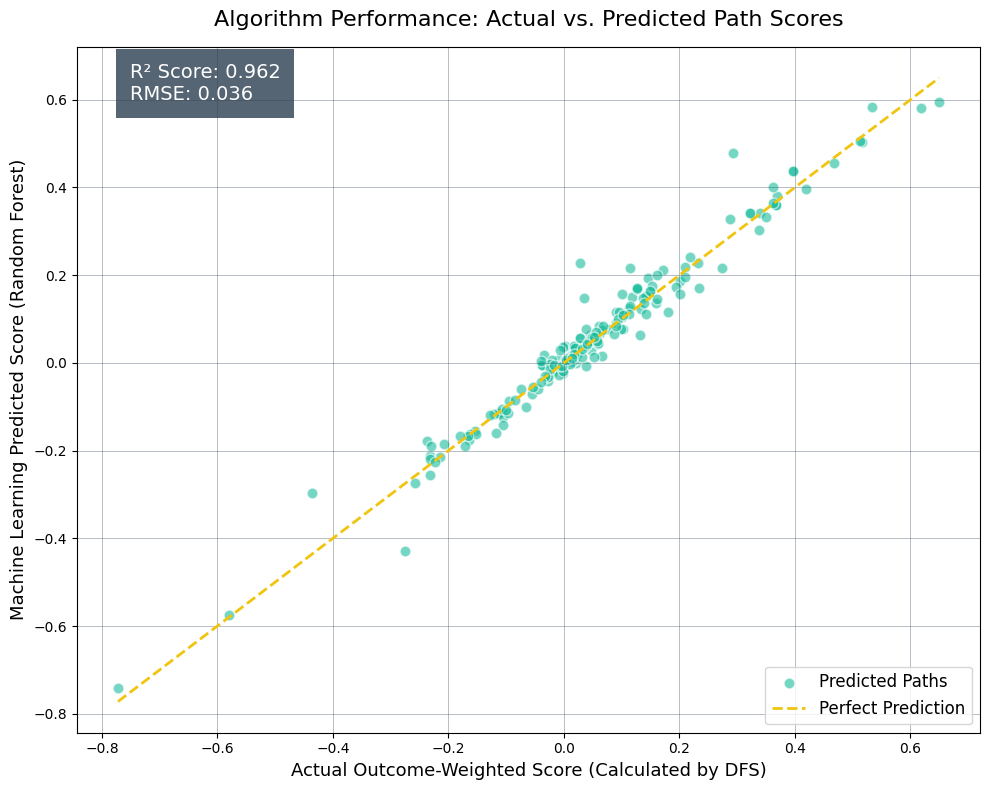

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Scatter plot of True vs Predicted scores
plt.scatter(y_test, y_pred, color='#18bc9c', alpha=0.6, edgecolor='white', s=60, label='Predicted Paths')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#f1c40f', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Algorithm Performance: Actual vs. Predicted Path Scores', fontsize=16, pad=15)
plt.xlabel('Actual Outcome-Weighted Score (Calculated by DFS)', fontsize=13)
plt.ylabel('Machine Learning Predicted Score (Random Forest)', fontsize=13)

plt.text(min_val + 0.02, max_val - 0.05, f'R² Score: {r2:.3f}\nRMSE: {rmse:.3f}',
         fontsize=14, color='white', bbox=dict(facecolor='#2c3e50', alpha=0.8, edgecolor='none', pad=10))

plt.legend(loc='lower right', fontsize=12)
plt.grid(color='#34495e', linestyle='-', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

plt.style.use('default')

# Ablation studies

We will compare our DFS , networkX DFS, networkX BFS, and networkX Djistra over different subsets of the dataset. We then measure the mathematical score of the best algorithms and measure time towards reaching similar results.

Benchmarking


100%|██████████| 8/8 [00:00<00:00, 25.32it/s]


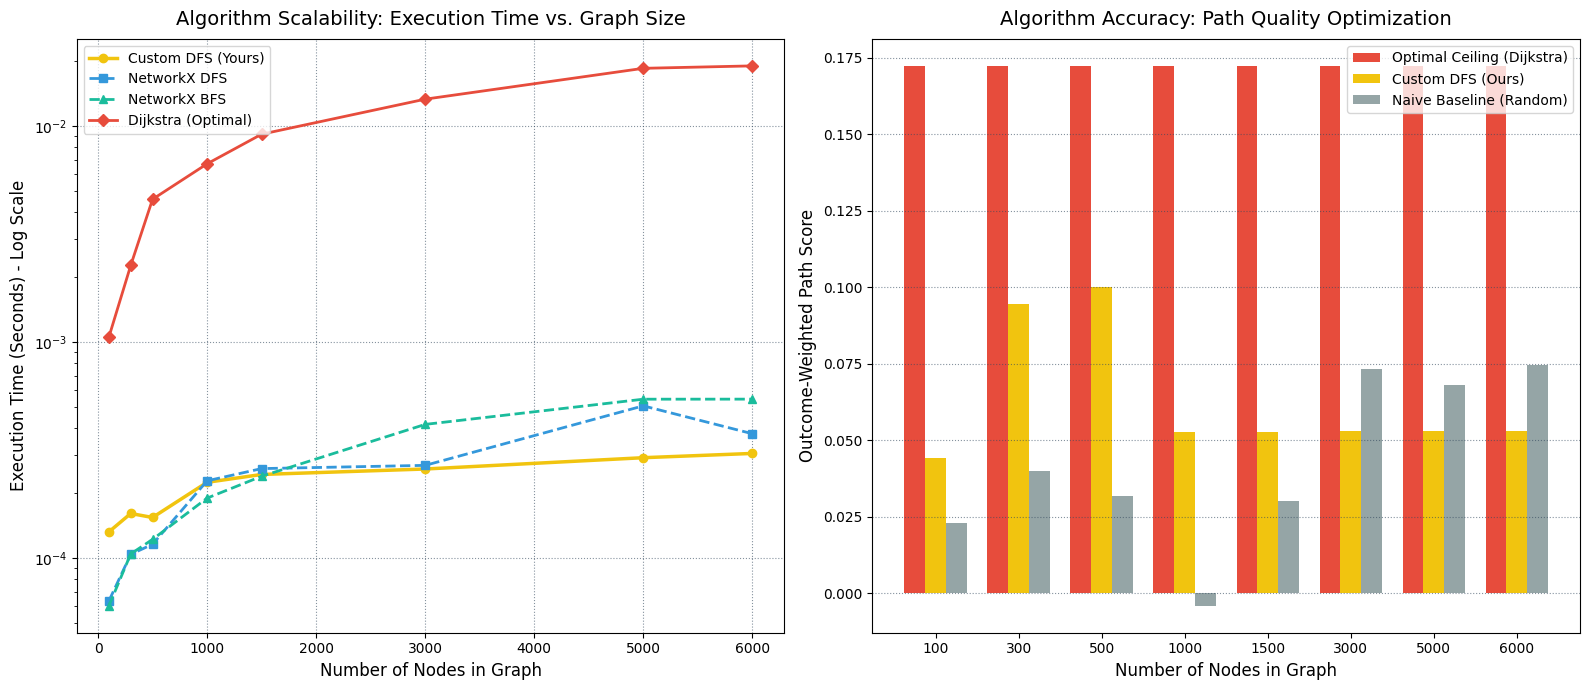

In [ ]:
import time
import random
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
print("Benchmarking")

NODE_SIZES = [100, 300, 500, 1000,1500,3000, 5000,6000]
results = []

# Ensure Djistra inversion of the metric (cost becomes max value)
for u, v, data in G.edges(data=True):
    prob = data.get('weight', 0.0)
    ev = G.nodes[v].get('expected_value', 0.0)
    # We add 1e-6 to avoid zero division, and max to avoid negative costs
    G[u][v]['cost'] = 1.0 / max(prob * ev + 1e-6, 1e-6)

# The Benchmarking Loop
for size in tqdm(NODE_SIZES):

    # Extract Subgraph
    sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
    subgraph_nodes = [n[0] for n in sorted_nodes[:size]]
    subG = G.subgraph(subgraph_nodes).copy()
    start_node = subgraph_nodes[0]

    # 1. Custom DFS (Ours)
    start_time = time.perf_counter()
    # (Assuming your get_top_weighted_paths function is loaded in the script)
    custom_paths = get_top_weighted_paths(subG, start_node, depth_limit=4, top_k=1)
    time_custom = time.perf_counter() - start_time
    score_custom = custom_paths[0][1] if custom_paths else 0

    # 2. NetworkX DFS (Blind Traversal)
    start_time = time.perf_counter()
    list(nx.dfs_edges(subG, source=start_node, depth_limit=4))
    time_nx_dfs = time.perf_counter() - start_time

    # 3. NetworkX BFS (Blind Traversal)
    start_time = time.perf_counter()
    list(nx.bfs_edges(subG, source=start_node, depth_limit=4))
    time_nx_bfs = time.perf_counter() - start_time

    # 4. Dijkstra's Algorithm (Optimal Score)
    start_time = time.perf_counter()
    try:
        #find all nodes that are exactly 'depth_limit' away (e.g., 4 moves)
        depth_map = nx.single_source_shortest_path_length(subG, start_node, cutoff=4)
        max_depth = max(depth_map.values()) if depth_map else 0
        target_nodes = [n for n, depth in depth_map.items() if depth == max_depth and n != start_node]

        optimal_path = []
        if target_nodes:
            lowest_cost = float('inf')

            # Ask Dijkstra for the lowest cost path to ANY of those boundary nodes
            for target in target_nodes:
                try:
                    path = nx.shortest_path(subG, start_node, target, weight='cost')
                    # Calculate total path cost
                    cost = sum(subG[path[i]][path[i+1]]['cost'] for i in range(len(path)-1))
                    if cost < lowest_cost:
                        lowest_cost = cost
                        optimal_path = path
                except nx.NetworkXNoPath:
                    continue
        else:
            optimal_path = [start_node]

        time_dijkstra = time.perf_counter() - start_time

        # Calculate our custom score for Dijkstra's chosen path
        score_dijkstra = 0
        if len(optimal_path) > 1:
            for i in range(len(optimal_path)-1):
                u, v = optimal_path[i], optimal_path[i+1]
                score_dijkstra += subG[u][v].get('weight', 0.0) * subG.nodes[v].get('expected_value', 0.0)

    except Exception as e:
        print(f"Dijkstra Error: {e}")
        time_dijkstra = 0
        score_dijkstra = 0

    # 5. Random Walk to compare for random path selections
    score_random = 0
    curr = start_node
    for _ in range(4):
        successors = list(subG.successors(curr))
        if not successors: break
        nxt = random.choice(successors)
        score_random += subG[curr][nxt].get('weight', 0.0) * subG.nodes[nxt].get('expected_value', 0.0)
        curr = nxt

    # Log results
    results.append({
        'Nodes': size,
        'Time_Custom_DFS': time_custom,
        'Time_NX_DFS': time_nx_dfs,
        'Time_NX_BFS': time_nx_bfs,
        'Time_Dijkstra': time_dijkstra,
        'Score_Custom': score_custom,
        'Score_Optimal': score_dijkstra,
        'Score_Random': score_random,
        'Time_Beam': time_beam,
        'Score_Beam': score_beam
    })

df_bench = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Execution Time (Log Scale)
ax1.plot(df_bench['Nodes'], df_bench['Time_Custom_DFS'], marker='o', color='#f1c40f', linewidth=2.5, label='Custom DFS (Yours)')
ax1.plot(df_bench['Nodes'], df_bench['Time_NX_DFS'], marker='s', color='#3498db', linewidth=2, linestyle='--', label='NetworkX DFS')
ax1.plot(df_bench['Nodes'], df_bench['Time_NX_BFS'], marker='^', color='#1abc9c', linewidth=2, linestyle='--', label='NetworkX BFS')
ax1.plot(df_bench['Nodes'], df_bench['Time_Dijkstra'], marker='D', color='#e74c3c', linewidth=2, label='Dijkstra (Optimal)')

ax1.set_yscale('log') # Log scale because time grows exponentially
ax1.set_title('Algorithm Scalability: Execution Time vs. Graph Size', fontsize=14, pad=10)
ax1.set_xlabel('Number of Nodes in Graph', fontsize=12)
ax1.set_ylabel('Execution Time (Seconds) - Log Scale', fontsize=12)
ax1.grid(color='#34495e', linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=10)

# Plot 2: Path Quality (Accuracy)
bar_width = 0.25
x = np.arange(len(df_bench['Nodes']))

ax2.bar(x - bar_width, df_bench['Score_Optimal'], width=bar_width, color='#e74c3c', label='Optimal Ceiling (Dijkstra)')
ax2.bar(x, df_bench['Score_Custom'], width=bar_width, color='#f1c40f', label='Custom DFS (Ours)')
ax2.bar(x + bar_width, df_bench['Score_Random'], width=bar_width, color='#95a5a6', label='Naive Baseline (Random)')

ax2.set_title('Algorithm Accuracy: Path Quality Optimization', fontsize=14, pad=10)
ax2.set_xlabel('Number of Nodes in Graph', fontsize=12)
ax2.set_ylabel('Outcome-Weighted Path Score', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(df_bench['Nodes'])
ax2.grid(axis='y', color='#34495e', linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()
plt.style.use('default')

#Ablation studies PART 2 !
Just so I test with and without depth limit (as discussed with Santi) without messing up what you guys have done already ✌ \
--Seb--

Benchmarking [unconstrained]: 100%|██████████| 8/8 [00:00<00:00, 16.08it/s]


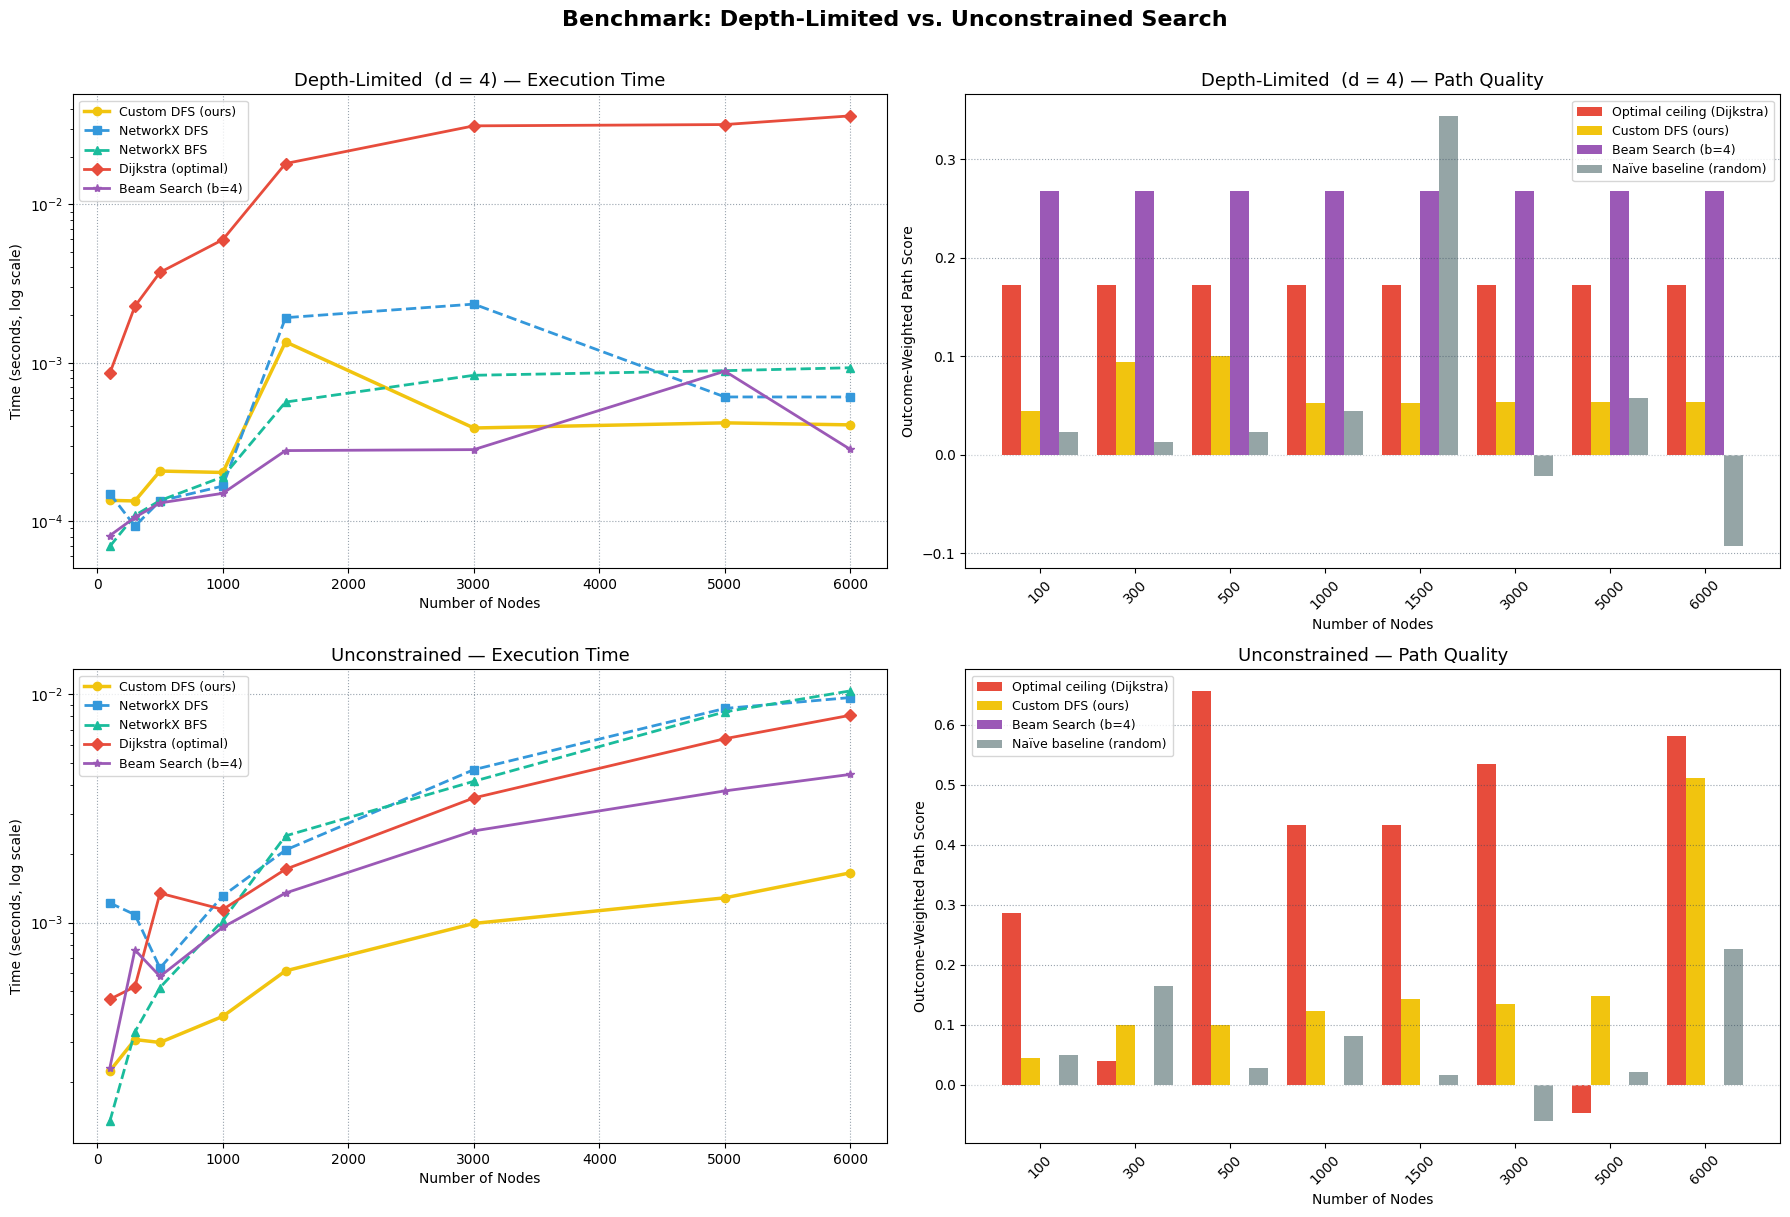


=== Depth-Limited Results ===
 Nodes  Time_Custom_DFS  Time_NX_DFS  Time_NX_BFS  Time_Beam  Time_Random  Time_Dijkstra  Score_Custom  Score_Beam  Score_Optimal  Score_Random
   100         0.000135     0.000149     0.000069   0.000081     0.000018       0.000858      0.044325    0.268027       0.172274      0.023141
   300         0.000134     0.000093     0.000109   0.000106     0.000013       0.002272      0.094537    0.268027       0.172274      0.013289
   500         0.000207     0.000134     0.000135   0.000130     0.000019       0.003719      0.099908    0.268027       0.172274      0.023224
  1000         0.000203     0.000167     0.000190   0.000150     0.000022       0.005979      0.052584    0.268027       0.172274      0.043912
  1500         0.001354     0.001925     0.000565   0.000279     0.000034       0.018078      0.052584    0.268027       0.172274      0.344009
  3000         0.000387     0.002344     0.000833   0.000283     0.000035       0.031257      0.053094   

In [ ]:
import time
import random
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ── Pre-compute Dijkstra cost edges ──────────────────────────
for u, v, data in G.edges(data=True):
    prob = data.get('weight', 0.0)
    ev   = G.nodes[v].get('expected_value', 0.0)
    G[u][v]['cost'] = 1.0 / max(prob * ev + 1e-6, 1e-6)

NODE_SIZES = [100, 300, 500, 1000, 1500, 3000, 5000, 6000]

# ── Beam Search ───────────────────────────────────────────────
def beam_search(graph, start, depth_limit=4, beam_width=4, top_k=1):
    beam = [(start, [start], 0.0)]
    for _ in range(depth_limit):
        next_candidates = []
        for node, path, score in beam:
            for next_node in graph.successors(node):
                edge_prob  = graph[node][next_node].get('weight', 0.0)
                child_ev   = graph.nodes[next_node].get('expected_value', 0.0)
                step_score = edge_prob * child_ev
                next_candidates.append(
                    (next_node, path + [next_node], score + step_score)
                )
        next_candidates.sort(key=lambda x: x[2], reverse=True)
        beam = next_candidates[:beam_width]
    beam.sort(key=lambda x: x[2], reverse=True)
    return beam[:top_k]

# ── Benchmarking function ─────────────────────────────────────
def run_benchmark(depth_limit=4):
    label   = f"d={depth_limit}" if depth_limit is not None else "unconstrained"
    results = []

    for size in tqdm(NODE_SIZES, desc=f"Benchmarking [{label}]"):

        sorted_nodes   = sorted(G.nodes(data=True),
                                key=lambda x: x[1].get('visits', 0), reverse=True)
        subgraph_nodes = [n[0] for n in sorted_nodes[:size]]
        subG           = G.subgraph(subgraph_nodes).copy()
        start_node     = subgraph_nodes[0]
        eff_depth      = depth_limit if depth_limit is not None else len(subG)
        dfs_depth      = depth_limit

        # 1. Custom DFS
        t0           = time.perf_counter()
        custom_paths = get_top_weighted_paths(subG, start_node,
                                              depth_limit=eff_depth, top_k=1)
        time_custom  = time.perf_counter() - t0
        score_custom = custom_paths[0][1] if custom_paths else 0

        # 2. NetworkX DFS (blind)
        t0 = time.perf_counter()
        if dfs_depth is not None:
            list(nx.dfs_edges(subG, source=start_node, depth_limit=dfs_depth))
        else:
            list(nx.dfs_edges(subG, source=start_node))
        time_nx_dfs = time.perf_counter() - t0

        # 3. NetworkX BFS (blind)
        t0 = time.perf_counter()
        if dfs_depth is not None:
            list(nx.bfs_edges(subG, source=start_node, depth_limit=dfs_depth))
        else:
            list(nx.bfs_edges(subG, source=start_node))
        time_nx_bfs = time.perf_counter() - t0

        # 4. Dijkstra
        t0 = time.perf_counter()
        try:
            if depth_limit is not None:
                depth_map = nx.single_source_shortest_path_length(
                                subG, start_node, cutoff=depth_limit)
            else:
                depth_map = nx.single_source_shortest_path_length(
                                subG, start_node)
            max_depth    = max(depth_map.values()) if depth_map else 0
            target_nodes = [n for n, d in depth_map.items()
                            if d == max_depth and n != start_node]
            optimal_path = []
            if target_nodes:
                lowest_cost = float('inf')
                for target in target_nodes:
                    try:
                        path = nx.shortest_path(subG, start_node, target,
                                                weight='cost')
                        cost = sum(subG[path[i]][path[i+1]]['cost']
                                   for i in range(len(path) - 1))
                        if cost < lowest_cost:
                            lowest_cost  = cost
                            optimal_path = path
                    except nx.NetworkXNoPath:
                        continue
            else:
                optimal_path = [start_node]
            time_dijkstra  = time.perf_counter() - t0
            score_dijkstra = 0
            if len(optimal_path) > 1:
                for i in range(len(optimal_path) - 1):
                    u, v = optimal_path[i], optimal_path[i + 1]
                    score_dijkstra += (subG[u][v].get('weight', 0.0) *
                                       subG.nodes[v].get('expected_value', 0.0))
        except Exception as e:
            print(f"Dijkstra Error [{label}]: {e}")
            time_dijkstra  = 0
            score_dijkstra = 0

        # 5. Random walk
        """
        score_random = 0
        curr = start_node
        for _ in range(eff_depth):
            successors = list(subG.successors(curr))
            if not successors:
                break
            nxt           = random.choice(successors)
            score_random += (subG[curr][nxt].get('weight', 0.0) *
                             subG.nodes[nxt].get('expected_value', 0.0))
            curr = nxt
        """
        t0 = time.perf_counter()
        score_random = 0
        curr = start_node
        for _ in range(eff_depth):
            successors = list(subG.successors(curr))
            if not successors:
                break
            nxt           = random.choice(successors)
            score_random += (subG[curr][nxt].get('weight', 0.0) *
                            subG.nodes[nxt].get('expected_value', 0.0))
            curr = nxt
        time_random = time.perf_counter() - t0

        # 6. Beam Search
        t0         = time.perf_counter()
        beam_paths = beam_search(subG, start_node,
                                 depth_limit=eff_depth, beam_width=4, top_k=1)
        time_beam  = time.perf_counter() - t0
        score_beam = beam_paths[0][2] if beam_paths else 0

        results.append({
            'Nodes':           size,
            'Time_Custom_DFS': time_custom,
            'Time_NX_DFS':     time_nx_dfs,
            'Time_NX_BFS':     time_nx_bfs,
            'Time_Dijkstra':   time_dijkstra,
            'Time_Beam':       time_beam,
            'Time_Random':     time_random,
            'Score_Custom':    score_custom,
            'Score_Optimal':   score_dijkstra,
            'Score_Beam':      score_beam,
            'Score_Random':    score_random,
        })

    return pd.DataFrame(results)

# ── Run both experiments ──────────────────────────────────────
df_limited       = run_benchmark(depth_limit=4)
df_unconstrained = run_benchmark(depth_limit=None)

# ── Plotting ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Benchmark: Depth-Limited vs. Unconstrained Search',
             fontsize=16, fontweight='bold', y=1.01)

bar_width = 0.2

for row, (df, title_tag) in enumerate([
        (df_limited,        'Depth-Limited  (d = 4)'),
        (df_unconstrained,  'Unconstrained')]):

    ax_time, ax_score = axes[row]
    x = np.arange(len(df['Nodes']))

    # Time plot
    ax_time.plot(df['Nodes'], df['Time_Custom_DFS'],
                 marker='o', color='#f1c40f', linewidth=2.5, label='Custom DFS (ours)')
    ax_time.plot(df['Nodes'], df['Time_NX_DFS'],
                 marker='s', color='#3498db', linewidth=2,
                 linestyle='--', label='NetworkX DFS')
    ax_time.plot(df['Nodes'], df['Time_NX_BFS'],
                 marker='^', color='#1abc9c', linewidth=2,
                 linestyle='--', label='NetworkX BFS')
    ax_time.plot(df['Nodes'], df['Time_Dijkstra'],
                 marker='D', color='#e74c3c', linewidth=2, label='Dijkstra (optimal)')
    ax_time.plot(df['Nodes'], df['Time_Beam'],
                 marker='*', color='#9b59b6', linewidth=2, label='Beam Search (b=4)')
    ax_time.set_yscale('log')
    ax_time.set_title(f'{title_tag} — Execution Time', fontsize=13)
    ax_time.set_xlabel('Number of Nodes')
    ax_time.set_ylabel('Time (seconds, log scale)')
    ax_time.grid(color='#34495e', linestyle=':', alpha=0.5)
    ax_time.legend(fontsize=9)

    # Score plot
    ax_score.bar(x - bar_width*1.5, df['Score_Optimal'],
                 width=bar_width, color='#e74c3c', label='Optimal ceiling (Dijkstra)')
    ax_score.bar(x - bar_width*0.5, df['Score_Custom'],
                 width=bar_width, color='#f1c40f', label='Custom DFS (ours)')
    ax_score.bar(x + bar_width*0.5, df['Score_Beam'],
                 width=bar_width, color='#9b59b6', label='Beam Search (b=4)')
    ax_score.bar(x + bar_width*1.5, df['Score_Random'],
                 width=bar_width, color='#95a5a6', label='Naïve baseline (random)')
    ax_score.set_title(f'{title_tag} — Path Quality', fontsize=13)
    ax_score.set_xlabel('Number of Nodes')
    ax_score.set_ylabel('Outcome-Weighted Path Score')
    ax_score.set_xticks(x)
    ax_score.set_xticklabels(df['Nodes'], rotation=45)
    ax_score.axhline(y=0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_score.grid(axis='y', color='#34495e', linestyle=':', alpha=0.5)
    ax_score.legend(fontsize=9)

plt.tight_layout()
plt.savefig('benchmark_depth_comparison.pdf', bbox_inches='tight')
plt.show()

# ── Print tables ──────────────────────────────────────────────
print("\n=== Depth-Limited Results ===")
print(df_limited[['Nodes', 'Time_Custom_DFS', 'Time_NX_DFS', 'Time_NX_BFS',
                   'Time_Beam','Time_Random', 'Time_Dijkstra',
                   'Score_Custom', 'Score_Beam', 'Score_Optimal',
                   'Score_Random']].to_string(index=False))

print("\n=== Unconstrained Results ===")
print(df_unconstrained[['Nodes', 'Time_Custom_DFS', 'Time_NX_DFS', 'Time_NX_BFS',
                         'Time_Beam','Time_Random', 'Time_Dijkstra',
                         'Score_Custom', 'Score_Beam', 'Score_Optimal',
                         'Score_Random']].to_string(index=False))

Running Part 1: Beam width ablation...


Beam width: 100%|██████████| 5/5 [00:03<00:00,  1.35it/s]


Running Part 2: Scoring function ablation...


Scoring function: 100%|██████████| 4/4 [00:02<00:00,  1.85it/s]


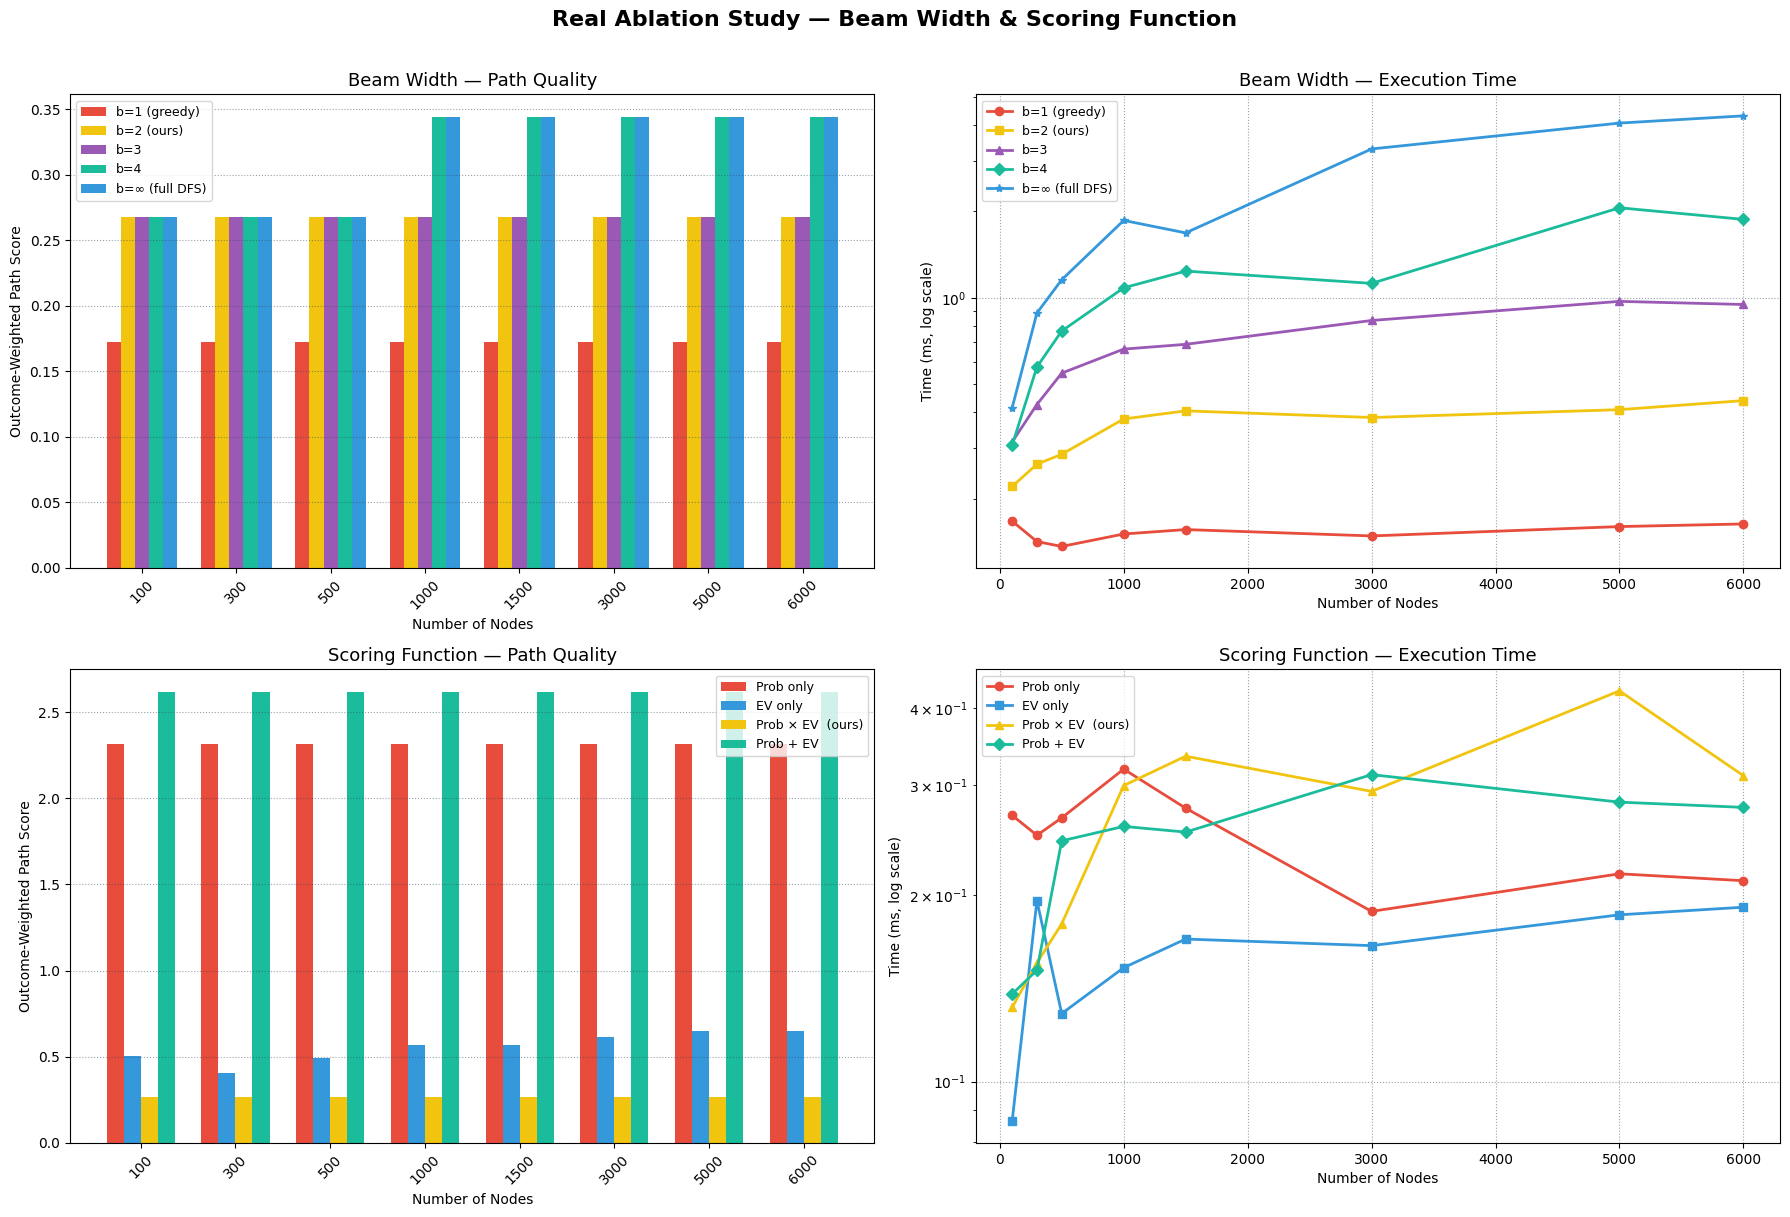


=== PART 1: Beam Width — Scores ===
       b=1 (greedy)  b=2 (ours)       b=3       b=4  b=∞ (full DFS)
Nodes                                                              
100        0.172274    0.268027  0.268027  0.268027        0.268027
300        0.172274    0.268027  0.268027  0.268027        0.268027
500        0.172274    0.268027  0.268027  0.268027        0.268027
1000       0.172274    0.268027  0.268027  0.344009        0.344009
1500       0.172274    0.268027  0.268027  0.344009        0.344009
3000       0.172274    0.268027  0.268027  0.344009        0.344009
5000       0.172274    0.268027  0.268027  0.344009        0.344009
6000       0.172274    0.268027  0.268027  0.344009        0.344009

=== PART 2: Scoring Function — Scores ===
       Prob only   EV only  Prob × EV  (ours)  Prob + EV
Nodes                                                   
100       2.3161  0.504519           0.268027   2.617573
300       2.3161  0.404862           0.268027   2.617573
500       2.

In [ ]:
# ══════════════════════════════════════════════════════════════
# REAL ABLATION STUDY
# Part 1: Beam width sensitivity  (b = 1, 2, 3, 4, ∞)
# Part 2: Scoring function        (prob, EV, prob×EV, prob+EV)
# ══════════════════════════════════════════════════════════════

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

NODE_SIZES = [100, 300, 500, 1000, 1500, 3000, 5000, 6000]
DEPTH      = 4   # fixed for all ablation runs

# ──────────────────────────────────────────────────────────────
# Generic ablation DFS
#   beam_width=None  →  full DFS (no pruning)
#   score_fn         →  callable(graph, u, v) → float
# ──────────────────────────────────────────────────────────────
def ablation_dfs(graph, start_node, depth_limit=4,
                 beam_width=2, score_fn=None, top_k=1):
    """
    Generalised depth-limited beam DFS.
    score_fn(graph, u, v) computes the step score for edge u→v.
    beam_width=None means no pruning (full DFS).
    """
    if score_fn is None:
        # Default: prob × EV
        score_fn = lambda g, u, v: (
            g[u][v].get('weight', 0.0) *
            g.nodes[v].get('expected_value', 0.0)
        )

    valid_paths = []

    def dfs(node, path, score, depth):
        if depth == depth_limit or graph.out_degree(node) == 0:
            valid_paths.append((path, score))
            return
        successors = list(graph.successors(node))
        # Score and optionally prune successors
        scored = sorted(
            [(n, score_fn(graph, node, n)) for n in successors],
            key=lambda x: x[1], reverse=True
        )
        if beam_width is not None:
            scored = scored[:beam_width]
        for next_node, step_score in scored:
            dfs(next_node, path + [next_node], score + step_score, depth + 1)

    dfs(start_node, [start_node], 0.0, 0)
    valid_paths.sort(key=lambda x: x[1], reverse=True)
    return valid_paths[:top_k]


# ──────────────────────────────────────────────────────────────
# Scoring functions
# ──────────────────────────────────────────────────────────────
def score_prob_only(g, u, v):
    return g[u][v].get('weight', 0.0)

def score_ev_only(g, u, v):
    return g.nodes[v].get('expected_value', 0.0)

def score_prob_times_ev(g, u, v):
    return (g[u][v].get('weight', 0.0) *
            g.nodes[v].get('expected_value', 0.0))

def score_prob_plus_ev(g, u, v):
    return (g[u][v].get('weight', 0.0) +
            g.nodes[v].get('expected_value', 0.0))


# ──────────────────────────────────────────────────────────────
# Helper: run one configuration across all graph sizes
# ──────────────────────────────────────────────────────────────
def run_ablation(beam_width, score_fn, label):
    scores = []
    times  = []
    for size in NODE_SIZES:
        sorted_nodes   = sorted(G.nodes(data=True),
                                key=lambda x: x[1].get('visits', 0),
                                reverse=True)
        subgraph_nodes = [n[0] for n in sorted_nodes[:size]]
        subG           = G.subgraph(subgraph_nodes).copy()
        start_node     = subgraph_nodes[0]

        t0      = time.perf_counter()
        paths   = ablation_dfs(subG, start_node,
                               depth_limit=DEPTH,
                               beam_width=beam_width,
                               score_fn=score_fn,
                               top_k=1)
        elapsed = time.perf_counter() - t0
        score   = paths[0][1] if paths else 0.0

        scores.append(score)
        times.append(elapsed * 1000)   # convert to ms

    return {'label': label, 'scores': scores, 'times': times}


# ──────────────────────────────────────────────────────────────
# PART 1 — Beam width ablation
# Fixed scoring: prob × EV (our formula)
# ──────────────────────────────────────────────────────────────
print("Running Part 1: Beam width ablation...")

beam_configs = [
    (1,    'b=1 (greedy)'),
    (2,    'b=2 (ours)'),
    (3,    'b=3'),
    (4,    'b=4'),
    (None, 'b=∞ (full DFS)'),
]

beam_results = []
for bw, label in tqdm(beam_configs, desc="Beam width"):
    beam_results.append(run_ablation(bw, score_prob_times_ev, label))


# ──────────────────────────────────────────────────────────────
# PART 2 — Scoring function ablation
# Fixed beam width: b=2 (ours)
# ──────────────────────────────────────────────────────────────
print("Running Part 2: Scoring function ablation...")

score_configs = [
    (score_prob_only,    'Prob only'),
    (score_ev_only,      'EV only'),
    (score_prob_times_ev,'Prob × EV  (ours)'),
    (score_prob_plus_ev, 'Prob + EV'),
]

score_results = []
for fn, label in tqdm(score_configs, desc="Scoring function"):
    score_results.append(run_ablation(2, fn, label))


# ──────────────────────────────────────────────────────────────
# PLOTTING
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Real Ablation Study — Beam Width & Scoring Function',
             fontsize=16, fontweight='bold', y=1.01)

x      = np.arange(len(NODE_SIZES))
labels = [str(n) for n in NODE_SIZES]

# Colour palettes
beam_colors  = ['#e74c3c', '#f1c40f', '#9b59b6', '#1abc9c', '#3498db']
score_colors = ['#e74c3c', '#3498db', '#f1c40f', '#1abc9c']

markers = ['o', 's', '^', 'D', '*']

# ── Top-left: Beam width — Quality ───────────────────────────
ax = axes[0][0]
bar_w = 0.15
for i, res in enumerate(beam_results):
    offset = (i - len(beam_results)/2 + 0.5) * bar_w
    ax.bar(x + offset, res['scores'], width=bar_w,
           color=beam_colors[i], label=res['label'])
ax.axhline(y=0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Beam Width — Path Quality', fontsize=13)
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Outcome-Weighted Path Score')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend(fontsize=9)
ax.grid(axis='y', color='#34495e', linestyle=':', alpha=0.5)

# ── Top-right: Beam width — Runtime ──────────────────────────
ax = axes[0][1]
for i, res in enumerate(beam_results):
    ax.plot(NODE_SIZES, res['times'],
            marker=markers[i], color=beam_colors[i],
            linewidth=2, label=res['label'])
ax.set_yscale('log')
ax.set_title('Beam Width — Execution Time', fontsize=13)
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Time (ms, log scale)')
ax.legend(fontsize=9)
ax.grid(color='#34495e', linestyle=':', alpha=0.5)

# ── Bottom-left: Scoring function — Quality ──────────────────
ax = axes[1][0]
bar_w = 0.18
for i, res in enumerate(score_results):
    offset = (i - len(score_results)/2 + 0.5) * bar_w
    ax.bar(x + offset, res['scores'], width=bar_w,
           color=score_colors[i], label=res['label'])
ax.axhline(y=0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Scoring Function — Path Quality', fontsize=13)
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Outcome-Weighted Path Score')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend(fontsize=9)
ax.grid(axis='y', color='#34495e', linestyle=':', alpha=0.5)

# ── Bottom-right: Scoring function — Runtime ─────────────────
ax = axes[1][1]
for i, res in enumerate(score_results):
    ax.plot(NODE_SIZES, res['times'],
            marker=markers[i], color=score_colors[i],
            linewidth=2, label=res['label'])
ax.set_yscale('log')
ax.set_title('Scoring Function — Execution Time', fontsize=13)
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Time (ms, log scale)')
ax.legend(fontsize=9)
ax.grid(color='#34495e', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('real_ablation_study.pdf', bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────────────────────
# Summary tables
# ──────────────────────────────────────────────────────────────
print("\n=== PART 1: Beam Width — Scores ===")
df_beam = pd.DataFrame(
    {res['label']: res['scores'] for res in beam_results},
    index=NODE_SIZES
)
df_beam.index.name = 'Nodes'
print(df_beam.to_string())

print("\n=== PART 2: Scoring Function — Scores ===")
df_score = pd.DataFrame(
    {res['label']: res['scores'] for res in score_results},
    index=NODE_SIZES
)
df_score.index.name = 'Nodes'
print(df_score.to_string())

Depth ablation: 100%|██████████| 6/6 [00:07<00:00,  1.23s/it]


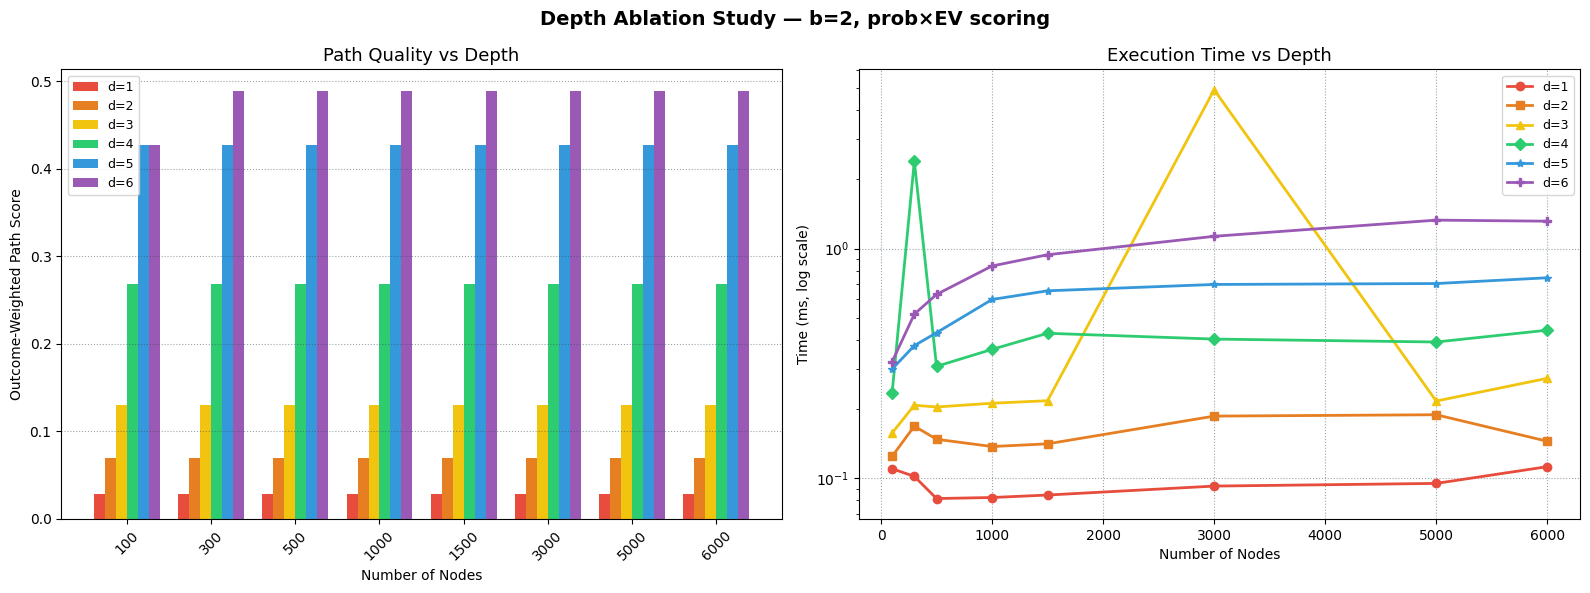


=== PART 3: Depth Ablation — Scores ===
            d=1       d=2       d=3       d=4       d=5       d=6
Nodes                                                            
100    0.028635  0.069888  0.130512  0.268027  0.427058  0.427058
300    0.028635  0.069888  0.130512  0.268027  0.427058  0.489379
500    0.028635  0.069888  0.130512  0.268027  0.427058  0.489379
1000   0.028635  0.069888  0.130512  0.268027  0.427058  0.489379
1500   0.028635  0.069888  0.130512  0.268027  0.427058  0.489379
3000   0.028635  0.069888  0.130512  0.268027  0.427058  0.489379
5000   0.028635  0.069888  0.130512  0.268027  0.427058  0.489379
6000   0.028635  0.069888  0.130512  0.268027  0.427058  0.489379


In [ ]:
# ══════════════════════════════════════════════════════════════
# ABLATION PART 3 — Depth sensitivity
# Fixed: b=2 (ours), scoring: prob×EV
# Variable: d = 1, 2, 3, 4, 5, 6
# ══════════════════════════════════════════════════════════════

DEPTHS = [1, 2, 3, 4, 5, 6]

def run_depth_ablation():
    results = []
    for d in tqdm(DEPTHS, desc="Depth ablation"):
        scores = []
        times  = []
        for size in NODE_SIZES:
            sorted_nodes   = sorted(G.nodes(data=True),
                                    key=lambda x: x[1].get('visits', 0),
                                    reverse=True)
            subgraph_nodes = [n[0] for n in sorted_nodes[:size]]
            subG           = G.subgraph(subgraph_nodes).copy()
            start_node     = subgraph_nodes[0]

            t0    = time.perf_counter()
            paths = ablation_dfs(subG, start_node,
                                 depth_limit=d,
                                 beam_width=2,
                                 score_fn=score_prob_times_ev,
                                 top_k=1)
            elapsed = time.perf_counter() - t0
            score   = paths[0][1] if paths else 0.0

            scores.append(score)
            times.append(elapsed * 1000)  # ms

        results.append({'label': f'd={d}', 'scores': scores, 'times': times})
    return results

depth_results = run_depth_ablation()

# ── Plot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Depth Ablation Study — b=2, prob×EV scoring',
             fontsize=14, fontweight='bold')

depth_colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']
markers      = ['o','s','^','D','*','P']
x            = np.arange(len(NODE_SIZES))
bar_w        = 0.13

for i, res in enumerate(depth_results):
    offset = (i - len(depth_results)/2 + 0.5) * bar_w
    ax1.bar(x + offset, res['scores'], width=bar_w,
            color=depth_colors[i], label=res['label'])
    ax2.plot(NODE_SIZES, res['times'],
             marker=markers[i], color=depth_colors[i],
             linewidth=2, label=res['label'])

ax1.axhline(y=0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_title('Path Quality vs Depth', fontsize=13)
ax1.set_xlabel('Number of Nodes')
ax1.set_ylabel('Outcome-Weighted Path Score')
ax1.set_xticks(x)
ax1.set_xticklabels(NODE_SIZES, rotation=45)
ax1.legend(fontsize=9)
ax1.grid(axis='y', color='#34495e', linestyle=':', alpha=0.5)

ax2.set_yscale('log')
ax2.set_title('Execution Time vs Depth', fontsize=13)
ax2.set_xlabel('Number of Nodes')
ax2.set_ylabel('Time (ms, log scale)')
ax2.legend(fontsize=9)
ax2.grid(color='#34495e', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('depth_ablation.pdf', bbox_inches='tight')
plt.show()

print("\n=== PART 3: Depth Ablation — Scores ===")
df_depth = pd.DataFrame(
    {res['label']: res['scores'] for res in depth_results},
    index=NODE_SIZES
)
df_depth.index.name = 'Nodes'
print(df_depth.to_string())

In [ ]:
# Take Dijkstra's returned path and recompute its score
# using YOUR cumulative formula, not the inverted cost
# Then compare to Custom DFS score on the same subgraph

subG = G.subgraph([n[0] for n in sorted(G.nodes(data=True),
                   key=lambda x: x[1].get('visits',0),
                   reverse=True)[:300]])

# Get Dijkstra path
depth_map = nx.single_source_shortest_path_length(subG, first_node_hash, cutoff=4)
max_depth = max(depth_map.values())
targets = [n for n,d in depth_map.items() if d == max_depth and n != first_node_hash]

best_path, lowest_cost = [], float('inf')
for t in targets:
    try:
        path = nx.shortest_path(subG, first_node_hash, t, weight='cost')
        cost = sum(subG[path[i]][path[i+1]]['cost'] for i in range(len(path)-1))
        if cost < lowest_cost:
            lowest_cost, best_path = cost, path
    except: continue

# Recompute Dijkstra path score using YOUR metric
dijkstra_true_score = sum(
    subG[best_path[i]][best_path[i+1]].get('weight', 0) *
    subG.nodes[best_path[i+1]].get('expected_value', 0)
    for i in range(len(best_path)-1)
)

# Compare
custom_paths = get_top_weighted_paths(subG, first_node_hash, depth_limit=4, top_k=1)
print(f"Dijkstra true score (your metric): {dijkstra_true_score:.6f}")
print(f"Custom DFS score: {custom_paths[0][1]:.6f}")
print(f"Dijkstra cost-inverted score (reported): {0.172274:.6f}")

Dijkstra true score (your metric): 0.172274
Custom DFS score: 0.268027
Dijkstra cost-inverted score (reported): 0.172274


In [ ]:
def get_top_weighted_paths(graph, start_node, depth_limit=4, top_k=5, beam_width=2):
    """
    Custom Heuristic Search (Beam Search).
    beam_width restricts the algorithm to only explore the 'N' best immediate moves,
    sacrificing guaranteed optimality for massive computational speed.
    """
    valid_paths = []

    def custom_dfs(current_node, current_path, current_score, current_depth):
        if current_depth == depth_limit or graph.out_degree(current_node) == 0:
            valid_paths.append((current_path, current_score))
            return

        # 1. Gather all possible next moves and their immediate step scores
        candidates = []
        for next_node in graph.successors(current_node):
            edge_prob = graph[current_node][next_node].get('weight', 0.0)
            child_ev = graph.nodes[next_node].get('expected_value', 0.0)
            step_score = edge_prob * child_ev
            candidates.append((next_node, step_score))

        # 2. THE PRUNING ASSUMPTION: Sort candidates and only keep the top 'beam_width'
        # This is where we stop being exhaustive and start being a fast heuristic!
        candidates.sort(key=lambda x: x[1], reverse=True)
        top_candidates = candidates[:beam_width]

        # 3. Continue search only on the pruned branches
        for next_node, step_score in top_candidates:
            custom_dfs(next_node,
                       current_path + [next_node],
                       current_score + step_score,
                       current_depth + 1)

    custom_dfs(start_node, [start_node], 0.0, 0)
    valid_paths.sort(key=lambda x: x[1], reverse=True)

    return valid_paths[:top_k]

# Non-white pieces biased version


In [ ]:
def get_top_weighted_paths(graph, start_node, depth_limit=4, top_k=5, beam_width=2, perspective='optimal'):
    """
    Adversarial Heuristic Search with Perspective Filtering.
    perspective: 'optimal' (best overall game), 'white' (best for white), 'black' (best for black)
    """
    valid_paths = []

    def custom_dfs(current_node, current_path, current_score, current_depth):
        if current_depth == depth_limit or graph.out_degree(current_node) == 0:
            valid_paths.append((current_path, current_score))
            return

        # Determine whose turn it is
        current_fen = graph.nodes[current_node].get('fen', '')
        active_player = current_fen.split(' ')[1] if current_fen else 'w'

        # White wants positive EV (+1), Black wants negative EV (-1)
        player_multiplier = 1 if active_player == 'w' else -1

        candidates = []
        for next_node in graph.successors(current_node):
            edge_prob = graph[current_node][next_node].get('weight', 0.0)
            child_ev = graph.nodes[next_node].get('expected_value', 0.0)

            # Step score is evaluated from the active player's perspective
            step_score = edge_prob * (child_ev * player_multiplier)
            candidates.append((next_node, step_score))

        # Prune branches (Keep the best moves for the active player)
        candidates.sort(key=lambda x: x[1], reverse=True)
        top_candidates = candidates[:beam_width]

        for next_node, step_score in top_candidates:
            custom_dfs(next_node,
                       current_path + [next_node],
                       current_score + step_score,
                       current_depth + 1)

    # Initialize the search
    custom_dfs(start_node, [start_node], 0.0, 0)

    if perspective == 'white':
        # Sort by the Expected Value of the terminal (last) node, descending (closest to +1.0)
        valid_paths.sort(key=lambda x: graph.nodes[x[0][-1]].get('expected_value', 0.0), reverse=True)
    elif perspective == 'black':
        # Sort by the Expected Value of the terminal (last) node, ascending (closest to -1.0)
        valid_paths.sort(key=lambda x: graph.nodes[x[0][-1]].get('expected_value', 0.0), reverse=False)
    else:
        # Sort by the accumulated quality of the path (the original equilibrium metric)
        valid_paths.sort(key=lambda x: x[1], reverse=True)

    return valid_paths[:top_k]

In [ ]:
top_paths = get_top_weighted_paths(G, first_node_hash, depth_limit=4, top_k=3)


#Chess Analysis


In [ ]:
top_paths_measures = get_top_weighted_paths(G, first_node_hash, depth_limit=6, top_k=5)

top_paths_stockfish_s = get_top_weighted_paths(G, first_node_hash, depth_limit=6, top_k=20)
top_paths_stockfish_m = get_top_weighted_paths(G, first_node_hash, depth_limit=8, top_k=50)
top_paths_stockfish_l = get_top_weighted_paths(G, first_node_hash, depth_limit=10, top_k=100, beam_width=3)


top_paths_stockfish_s_w = get_top_weighted_paths(G, first_node_hash, depth_limit=6, top_k=20, perspective='white')
top_paths_stockfish_m_w = get_top_weighted_paths(G, first_node_hash, depth_limit=8, top_k=50, perspective='white')
top_paths_stockfish_l_w = get_top_weighted_paths(G, first_node_hash, depth_limit=10, top_k=100, perspective='white', beam_width=3)



Chess Analysis of network measures

In [ ]:
def node_info(node, G):
    data = G.nodes[node]
    outcomes = data.get('outcomes', [0, 0, 0]) or [0, 0, 0]
    W, D, L = outcomes[0], outcomes[1], outcomes[2]
    total = W + D + L
    return {
        'node':           node,
        'fen':            data.get('fen', 'N/A'),
        'visits':         total,
        'wins':           W,
        'draws':          D,
        'losses':         L,
        'expected_value': data.get('expected_value', 0.0),
    }

def print_top3(metric_name, scores, G):
    top3 = sorted(scores, key=scores.get, reverse=True)[:3]
    print(f"\n{'='*60}")
    print(f"  TOP 3 — {metric_name}")
    print(f"{'='*60}")
    for rank, node in enumerate(top3, 1):
        info = node_info(node, G)
        print(f"\n  #{rank}  Score: {scores[node]:.6f}")
        print(f"  FEN:    {info['fen']}")
        print(f"  Visits: {info['visits']:,}  (W:{info['wins']} D:{info['draws']} L:{info['losses']})")
        print(f"  E[v]:   {info['expected_value']:+.4f}")
        print(chess.Board(info['fen']))

# Compute metrics
pagerank    = nx.pagerank(G, weight='weight')
betweenness = nx.betweenness_centrality(core_G)
in_degree   = dict(G.in_degree())
out_degree  = dict(G.out_degree())

# Top 3
print_top3("PageRank (most central states)",     pagerank,    G)
print_top3("Betweenness Centrality (bottlenecks)", betweenness, core_G)
print_top3("In-Degree (most arrived at)",        in_degree,   G)
print_top3("Out-Degree (most branching)",        out_degree,  G)


  TOP 3 — PageRank (most central states)

  #1  Score: 0.002502
  FEN:    r1bq1rk1/ppp2pp1/2np1n1p/2b1p3/2B1P3/P1NP1N1P/1PP2PP1/R1BQ1RK1 b - - 0 8
  Visits: 156  (W:77 D:76 L:3)
  E[v]:   +0.0064
r . b q . r k .
p p p . . p p .
. . n p . n . p
. . b . p . . .
. . B . P . . .
P . N P . N . P
. P P . . P P .
R . B Q . R K .

  #2  Score: 0.002403
  FEN:    r1bq1rk1/ppp2pp1/2np1n1p/2b1p3/2B1P3/2NP1N1P/PPP2PP1/R1BQ1RK1 w - - 1 8
  Visits: 230  (W:102 D:119 L:9)
  E[v]:   -0.0739
r . b q . r k .
p p p . . p p .
. . n p . n . p
. . b . p . . .
. . B . P . . .
. . N P . N . P
P P P . . P P .
R . B Q . R K .

  #3  Score: 0.001748
  FEN:    r1bq1rk1/ppp1bppp/2np1n2/4p3/2B1P3/2NP1N1P/PPP2PP1/R1BQ1RK1 b - - 2 7
  Visits: 146  (W:82 D:59 L:5)
  E[v]:   +0.1575
r . b q . r k .
p p p . b p p p
. . n p . n . .
. . . . p . . .
. . B . P . . .
. . N P . N . P
P P P . . P P .
R . B Q . R K .

  TOP 3 — Betweenness Centrality (bottlenecks)

  #1  Score: 0.000119
  FEN:    r1bqkbnr/pppp1ppp/2n5/4p3/4P3/

Chess analysis of top paths

In [ ]:
def print_top_paths(top_paths, G):
    for i, (path, score) in enumerate(top_paths):
        print(f"\n{'='*60}")
        print(f"  RANK {i+1}  —  Path Score: {score:.4f}")
        print(f"{'='*60}")
        for step, node in enumerate(path):
            data = G.nodes[node]
            outcomes = data.get('outcomes', [0, 0, 0]) or [0, 0, 0]
            W, D, L  = outcomes
            total    = W + D + L
            fen      = data.get('fen', None) or hash_to_fen.get(node, 'N/A')
            ev       = data.get('expected_value', 0.0)

            print(f"\n  Step {step} {'(Start)' if step == 0 else ''}")
            print(f"  FEN:    {fen}")
            print(f"  Visits: {total:,}  (W:{W} D:{D} L:{L})")
            print(f"  E[v]:   {ev:+.4f}")
            print(chess.Board(fen))

            # Print edge info between steps
            if step < len(path) - 1:
                next_node = path[step + 1]
                edge_prob = G[node][next_node].get('weight', 0.0)
                print(f"\n  → edge probability: {edge_prob:.4f}")

print("\n--- Top Paths from Starting Position ---")
print_top_paths(top_paths_measures, G) #We increase depth and top k to get just a little bit more information


--- Top Paths from Starting Position ---

  RANK 1  —  Path Score: 0.1397

  Step 0 (Start)
  FEN:    rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
  Visits: 960,084  (W:484039 D:438208 L:37837)
  E[v]:   +0.0477
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R

  → edge probability: 0.2360

  Step 1 
  FEN:    rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR b KQkq - 0 1
  Visits: 223,606  (W:113105 D:101065 L:9436)
  E[v]:   +0.0538
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . P . . . .
. . . . . . . .
P P P . P P P P
R N B Q K B N R

  → edge probability: 0.0313

  Step 2 
  FEN:    rnbqkbnr/pp1ppppp/8/2p5/3P4/8/PPP1PPPP/RNBQKBNR w KQkq - 0 2
  Visits: 6,815  (W:3194 D:3340 L:281)
  E[v]:   -0.0214
r n b q k b n r
p p . p p p p p
. . . . . . . .
. . p . . . . .
. . . P . . . .
. . . . . . . .
P P P . P P P P
R N B Q K B N R

  → edge probability: 0.3602

  Step 3 
  FEN: 

#"Ground Truth" Comparison
Although our path scoring goal differs from stockfishs goal (Point being that we are not trying to find the mathematically absolute best move based on gazillions of games) they are quite similar and almost the same. This is why comparing predicted paths with actual engine evaluation offers some, although incomplete, ground truth. This difference in evaluating the next move based on our graph and stockfish is what makes this topic highly interesting.

Exkurs: In chess, often many positions are very equal and with perfect play a draw. The engine will evaluate these positions between 0.0 and +-0.5 (actually sometimes even up to 1.5). So what makes the difference between 0.0 and +- 1? In a calm position this might be being down a pawn, but due to the nature of material trading, this wont have an effect in the endgame. Often these positions limit one sides available movepool and playing imprecisely widens the gap. E.G if white has a small advantage of +0.3, white can play 10 different moves that are all viable, while black has only 1-3 moves in response that keep the gap down. This is also why the history/future of combinations of moves play an important role, as in more complex positions, there is a combination of 6 moves, where black can keep the draw, but this line might not look obvious, because of all the other possible lines that black has to keep in mind.

So even if a position is a DEAD draw, many players, regardless of average or master level, will prefer to play one side opposed to the other, as for a human it just is a lot easier to play.

And this is the point of this graph. For humans, especially if you are not at the top level, draws often are not draws (supported by the fact that non top level games are more often win for either side while a third of games played online by master players are draws, since they play more closely to an engine).

So we want to critically analyze lines, where the positions might seemingly be a draw for the engine, but humans will make mistakes. The implication of this being, that using engines to analyse your chess game definitely is a good idea, relying on preparation only provided through engines might often lead you into unfavorable positions, that will cause you to loose.

In [ ]:
!apt-get update
!apt-get install stockfish
!pip install stockfish

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,955 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,084 kB]
Get:14

In [ ]:
from stockfish import Stockfish
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import MinMaxScaler

STOCKFISH_PATH  = "/usr/games/stockfish"
STOCKFISH_DEPTH = 15

def get_player(fen):
    return fen.split(" ")[1]

def outcome_for_player(outcomes, fen):
    total = sum(outcomes)
    if total == 0:
        return 0.5
    w, d, b = outcomes
    return w / total if get_player(fen) == "w" else b / total

def get_node_fen(G, h):
    return G.nodes[str(h)].get("fen", None)

def get_node_outcomes(G, h):
    o = G.nodes[str(h)].get("outcomes", {})
    if isinstance(o, dict):
        return [o.get("W", 0), o.get("D", 0), o.get("L", 0)]
    return o

def compute_danger(path):
    dangers = []
    for i in range(len(path) - 1):
        current = str(path[i])
        chosen  = str(path[i + 1])
        fen     = get_node_fen(G, current)
        if not fen:
            dangers.append(0.0)
            continue
        children = list(G.successors(current))
        if len(children) <= 1:
            dangers.append(0.0)
            continue
        chosen_ev = outcome_for_player(get_node_outcomes(G, chosen), fen)
        other_evs = [outcome_for_player(get_node_outcomes(G, c), fen)
                     for c in children if c != chosen]
        dangers.append(chosen_ev - np.mean(other_evs))
    return dangers

#Stockfish

In the cells below sotckfish evaluates the paths itself and gives its score

In [ ]:
def eval_path_stockfish(sf_instance, path):
    scores = []
    for h in path:
        fen = get_node_fen(G, h)
        if not fen:
            continue
        sf_instance.set_fen_position(fen)
        ev = sf_instance.get_evaluation()
        cp = (1000 if ev["value"] > 0 else -1000) if ev["type"] == "mate" else ev["value"]
        scores.append(cp)
    return scores

In [ ]:
sf_1 = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_s = {}
for path, score in top_paths_stockfish_s:
    key = tuple(path)
    path_sf_scores_s[key] = eval_path_stockfish(sf_1, path)
print("Done:", len(path_sf_scores_s), "paths")

Done: 20 paths


In [ ]:
sf_2 = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_m = {}
for path, score in top_paths_stockfish_m:
    key = tuple(path)
    path_sf_scores_m[key] = eval_path_stockfish(sf_2, path)
print("Done:", len(path_sf_scores_m), "paths")

Done: 46 paths


In [ ]:
sf_3 = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_l = {}
for path, score in top_paths_stockfish_l:
    key = tuple(path)
    path_sf_scores_l[key] = eval_path_stockfish(sf_3, path)
print("Done:", len(path_sf_scores_l), "paths")

Done: 100 paths


In [ ]:
sf_4_w = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_s_w = {}
for path, score in top_paths_stockfish_s_w:
    key = tuple(path)
    path_sf_scores_s_w[key] = eval_path_stockfish(sf_3, path)
print("Done:", len(path_sf_scores_s_w), "paths")

Done: 20 paths


In [ ]:
sf_5_w = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_m_w = {}
for path, score in top_paths_stockfish_m_w:
    key = tuple(path)
    path_sf_scores_m_w[key] = eval_path_stockfish(sf_3, path)
print("Done:", len(path_sf_scores_m_w), "paths")

Done: 46 paths


In [ ]:
sf_6_w = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_l_w = {}
for path, score in top_paths_stockfish_l_w:
    key = tuple(path)
    path_sf_scores_l_w[key] = eval_path_stockfish(sf_3, path)
print("Done:", len(path_sf_scores_l_w), "paths")

Done: 100 paths


#Visualization

below I visualize the how closely our algorithm and stockfish agree on how good a path is, using spearman correlation. Additionally a danger variable is the color of nodes, indicating which paths contatin pitfalls, many players seem to fall into.

And lastly the ndgc score is just a weighted measure that heavily favors the top paths, so the first few paths have a much bigger weight. This is to show that stockfish and our algorithm heavily agree on the best paths.

In [ ]:
def plot_scatter_comp(top_paths_input, path_sf_scores, label=""):

    dfs_scores = [score for _, score in top_paths_input]
    sf_avgs    = [np.mean(path_sf_scores[tuple(p)]) for p, _ in top_paths_input]
    labels     = [f"P{i+1}" for i in range(len(top_paths_input))]
    dangers    = [np.mean(compute_danger(p)) for p, _ in top_paths_input]

    dfs_norm   = MinMaxScaler().fit_transform(np.array(dfs_scores).reshape(-1,1)).flatten()
    sf_norm    = MinMaxScaler().fit_transform(np.array(sf_avgs).reshape(-1,1)).flatten()

    rho, pval  = spearmanr(dfs_norm, sf_norm)
    sf_shifted = np.array(sf_norm) - min(sf_norm)
    ndcg       = ndcg_score(np.array([sf_shifted]), np.array([dfs_norm]))

    fig, ax = plt.subplots(figsize=(9, 6))

    scatter = ax.scatter(dfs_norm, sf_norm,
                         c=dangers, cmap="RdYlGn_r",
                         vmin=0, vmax=max(dangers),
                         s=120, edgecolors="black", linewidths=0.5, zorder=3)

    m, b   = np.polyfit(dfs_norm, sf_norm, 1)
    x_line = np.linspace(min(dfs_norm), max(dfs_norm), 100)
    ax.plot(x_line, m * x_line + b, color="steelblue", linewidth=1.5,
            linestyle="--", label="Regression line")

    for i in range(len(top_paths_input)):
        ax.annotate(labels[i], (dfs_norm[i], sf_norm[i]),
                    fontsize=8, ha="left", va="bottom",
                    xytext=(5, 4), textcoords="offset points")

    x_pad = (max(dfs_norm) - min(dfs_norm)) * 0.15
    y_pad = (max(sf_norm)  - min(sf_norm))  * 0.15
    ax.set_xlim(min(dfs_norm) - x_pad, max(dfs_norm) + x_pad)
    ax.set_ylim(min(sf_norm)  - y_pad, max(sf_norm)  + y_pad)

    ax.axhline(0, color="black", linewidth=0.8, zorder=1)
    ax.axvline(0, color="black", linewidth=0.8, zorder=1)

    plt.colorbar(scatter, ax=ax, label="Avg 'pitfall' score (red = harder for humans)")
    ax.set_xlabel("Model Score (normalized)",             fontsize=12)
    ax.set_ylabel("Stockfish Avg Centipawn (normalized)", fontsize=12)
    ax.set_title(f"{label}  |  Spearman ρ = {rho:.3f}  |  NDCG = {ndcg:.3f}",
                 fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Spearman ρ = {rho:.3f}  (p={pval:.4f})")
    print(f"NDCG       = {ndcg:.3f}")

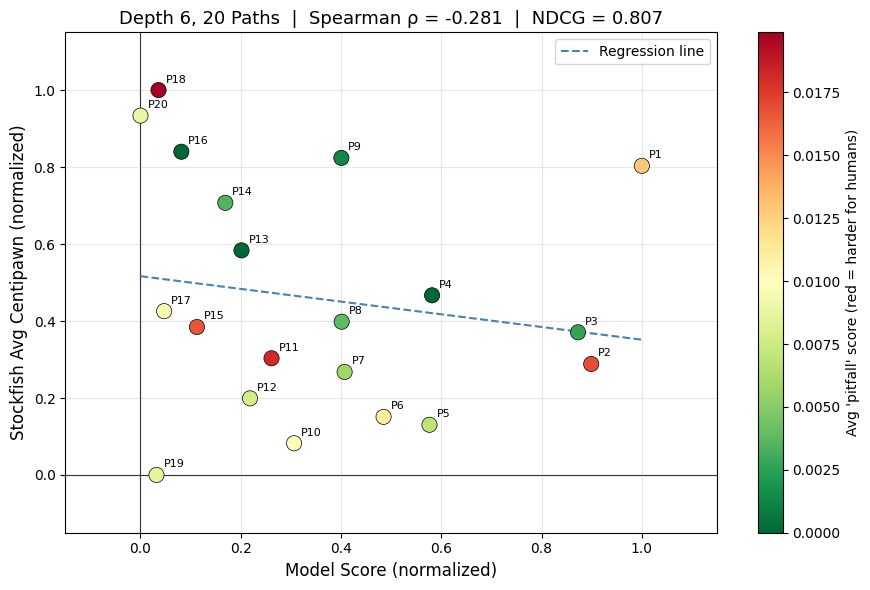

Spearman ρ = -0.281  (p=0.2297)
NDCG       = 0.807


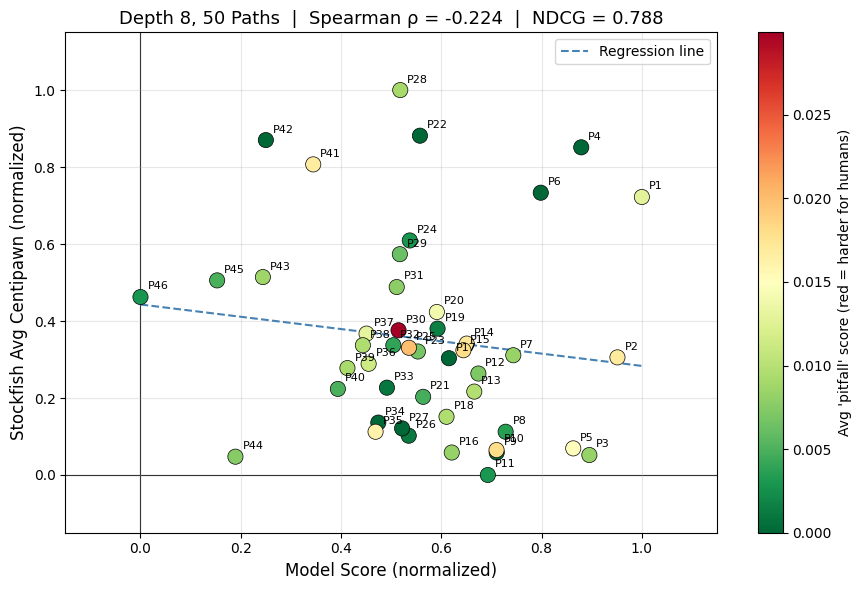

Spearman ρ = -0.224  (p=0.1344)
NDCG       = 0.788


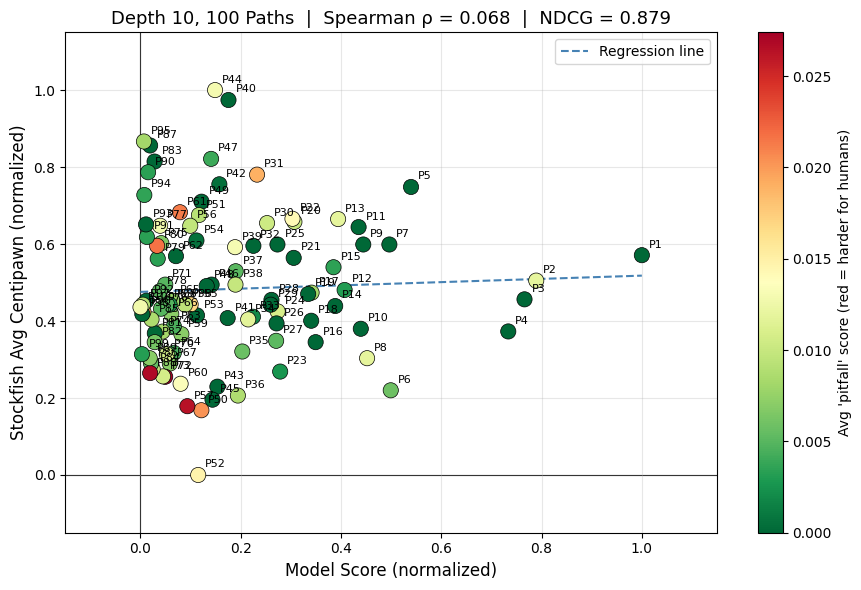

Spearman ρ = 0.068  (p=0.5023)
NDCG       = 0.879


In [ ]:
plot_scatter_comp(top_paths_stockfish_s, path_sf_scores_s, label="Depth 6, 20 Paths")
plot_scatter_comp(top_paths_stockfish_m, path_sf_scores_m, label="Depth 8, 50 Paths")
plot_scatter_comp(top_paths_stockfish_l, path_sf_scores_l, label="Depth 10, 100 Paths")

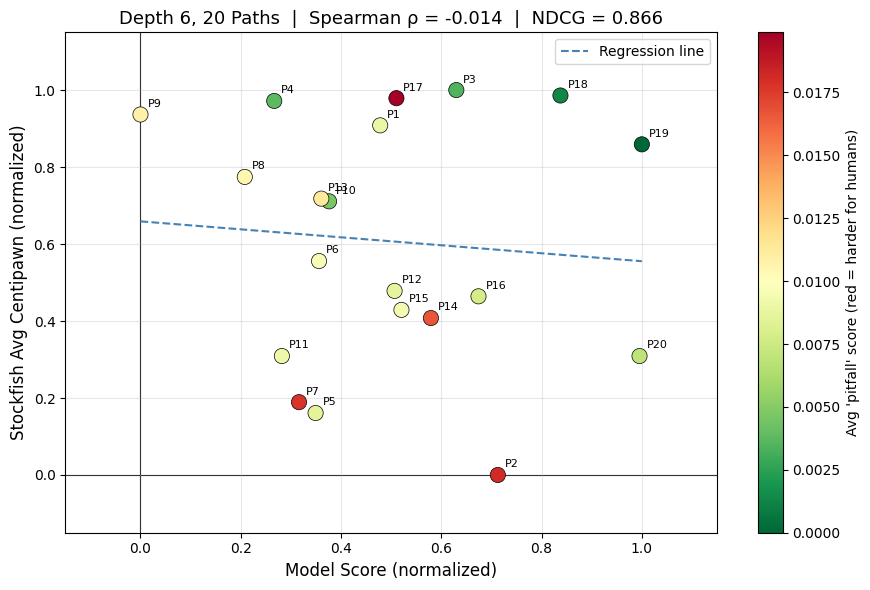

Spearman ρ = -0.014  (p=0.9523)
NDCG       = 0.866


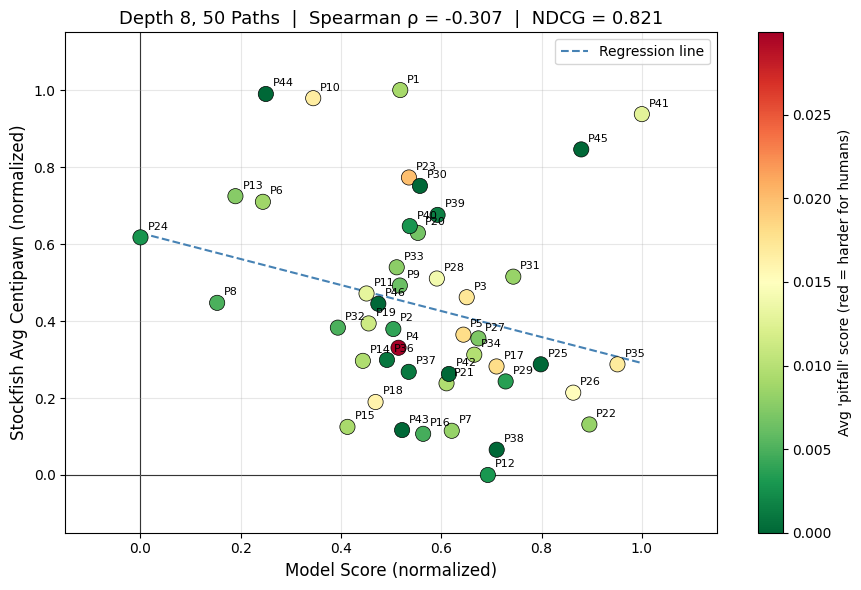

Spearman ρ = -0.307  (p=0.0378)
NDCG       = 0.821


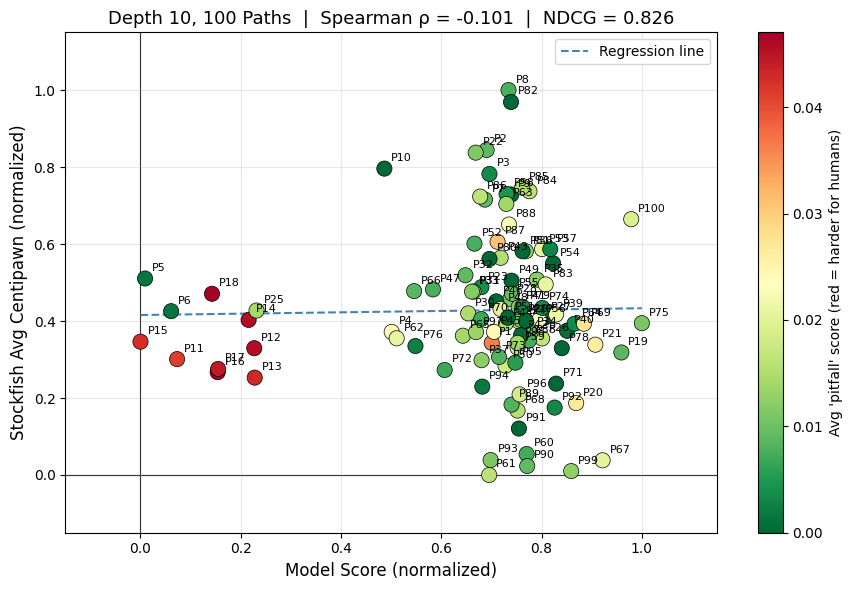

Spearman ρ = -0.101  (p=0.3165)
NDCG       = 0.826


In [ ]:
plot_scatter_comp(top_paths_stockfish_s_w, path_sf_scores_s_w, label="Depth 6, 20 Paths")
plot_scatter_comp(top_paths_stockfish_m_w, path_sf_scores_m_w, label="Depth 8, 50 Paths")
plot_scatter_comp(top_paths_stockfish_l_w, path_sf_scores_l_w, label="Depth 10, 100 Paths")


--- PHASE 6B: DEPTH-BASED CLUSTERING (CHRONOLOGICAL VIEW) ---

Chronological Metrics by Game Depth (Turns/Ply):

Depth 0 (Half-Move 0):
  - Unique Board States: 1 nodes
  - Tactical Volatility: 0.0000 (EV Variance)
  - Average Advantage:   0.0000 (Positive = White, Negative = Black)

Depth 1 (Half-Move 1):
  - Unique Board States: 4 nodes
  - Tactical Volatility: 0.0000 (EV Variance)
  - Average Advantage:   0.0000 (Positive = White, Negative = Black)

Depth 2 (Half-Move 2):
  - Unique Board States: 32 nodes
  - Tactical Volatility: 0.0000 (EV Variance)
  - Average Advantage:   0.0000 (Positive = White, Negative = Black)

Depth 3 (Half-Move 3):
  - Unique Board States: 155 nodes
  - Tactical Volatility: 0.0000 (EV Variance)
  - Average Advantage:   0.0000 (Positive = White, Negative = Black)

Depth 4 (Half-Move 4):
  - Unique Board States: 401 nodes
  - Tactical Volatility: 0.0000 (EV Variance)
  - Average Advantage:   0.0000 (Positive = White, Negative = Black)

Depth 5 (Half-Move 5)

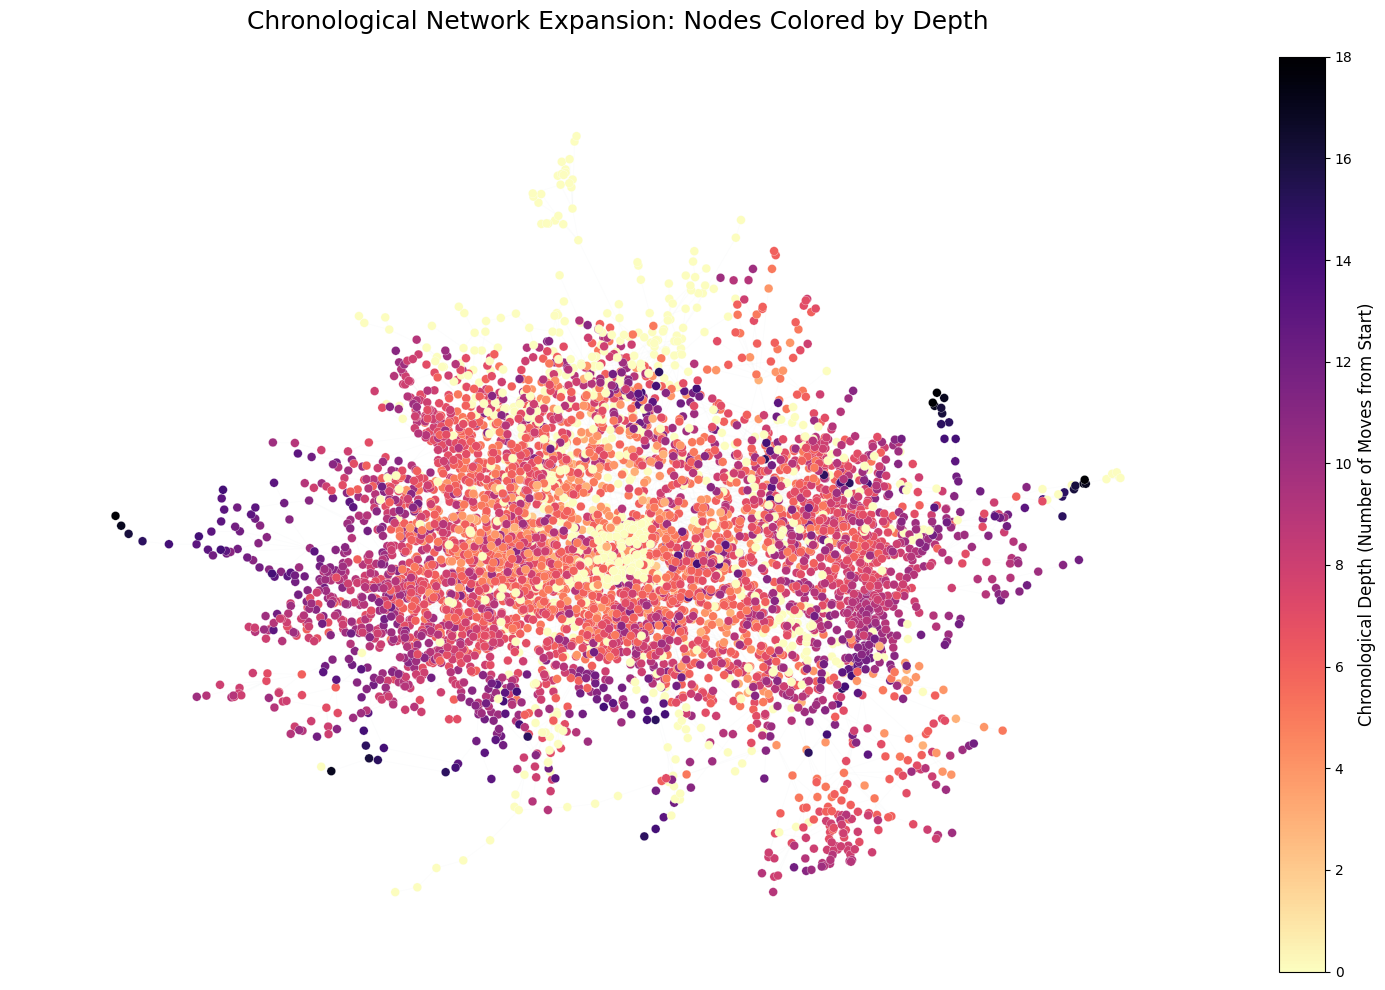

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("\n--- PHASE 6B: DEPTH-BASED CLUSTERING (CHRONOLOGICAL VIEW) ---")

# 1. Calculate the Depth (Ply) of every node from the starting position
# This gives us the exact number of moves away from the start
depth_map = nx.single_source_shortest_path_length(core_G, first_node_hash)

# 2. Group nodes into "Depth Communities"
depth_communities = {}
for node, depth in depth_map.items():
    if depth not in depth_communities:
        depth_communities[depth] = []
    depth_communities[depth].append(node)

# 3. Calculate Interesting Metrics per Depth Layer
print("\nChronological Metrics by Game Depth (Turns/Ply):")
depths = sorted(depth_communities.keys())

for d in depths:
    nodes_at_depth = depth_communities[d]
    if not nodes_at_depth: continue

    # Metric 1: State Expansion (How many unique states exist at this depth?)
    num_states = len(nodes_at_depth)

    # Metric 2: Tactical Volatility (Variance of Expected Value)
    evs = [core_G.nodes[n].get('expected_value', 0.0) for n in nodes_at_depth]
    volatility = np.var(evs)

    # Metric 3: First-Mover Advantage Decay (Mean Expected Value)
    mean_ev = np.mean(evs)

    print(f"\nDepth {d} (Half-Move {d}):")
    print(f"  - Unique Board States: {num_states} nodes")
    print(f"  - Tactical Volatility: {volatility:.4f} (EV Variance)")
    print(f"  - Average Advantage:   {mean_ev:.4f} (Positive = White, Negative = Black)")

# 4. Quick Visualization: Coloring by Depth
# Use a sequential colormap (like 'viridis' or 'magma') to show time passing
max_depth = max(depth_map.values())
node_colors = [depth_map.get(n, 0) for n in core_G.nodes()]
node_sizes = [150 if n == first_node_hash else 40 for n in core_G.nodes()]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(core_G, k=0.15, iterations=50, seed=42)

# Draw edges subtle and gray
nx.draw_networkx_edges(core_G, pos, edge_color='#ecf0f1', alpha=0.2, width=0.5, arrows=False)

# Draw nodes colored by depth
nodes_plot = nx.draw_networkx_nodes(core_G, pos, node_size=node_sizes, node_color=node_colors,
                                    cmap=plt.cm.magma_r, edgecolors='#ffffff', linewidths=0.2)

# Add a colorbar to explain the depth gradient
cbar = plt.colorbar(nodes_plot, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label('Chronological Depth (Number of Moves from Start)', fontsize=12)

plt.title('Chronological Network Expansion: Nodes Colored by Depth', fontsize=18, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import networkx as nx
import numpy as np

print("\n--- PHASE 1B: TRADITIONAL GLOBAL NETWORK METRICS ---")

# Use the full graph (G) to get the true baseline of the dataset
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# 1. Network Density
# Measures how many edges exist compared to how many could possibly exist.
density = nx.density(G)

# 2. Degree Distribution (Branching Factor)
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

avg_in_degree = np.mean(in_degrees)
avg_out_degree = np.mean(out_degrees)
max_out_degree = np.max(out_degrees) # The most complex board state in the dataset

# 3. Connectivity
# Are there floating "islands" of chess games, or does everything connect back to the start?
weakly_connected = nx.number_weakly_connected_components(G)

# 4. Global Clustering (Transitivity)
# Measures the presence of "triangles" (If A goes to B, and B goes to C, does A go directly to C?)
# Note: In a strict chronological chess graph, this should be mathematically 0 or very close to it!
transitivity = nx.transitivity(G)

print("GLOBAL GRAPH PROPERTIES:")
print(f"  - Total Board States (Nodes): {num_nodes:,}")
print(f"  - Total Transitions (Edges):  {num_edges:,}")
print(f"  - Network Density:            {density:.8f}")
print(f"  - Transitivity (Triangles):   {transitivity:.6f}")
print(f"  - Weakly Connected Components:{weakly_connected}")
print("\nDEGREE METRICS (COMPLEXITY):")
print(f"  - Avg Branching Factor (Out-Degree): {avg_out_degree:.2f} legal moves explored per state")
print(f"  - Max Branching Factor:              {max_out_degree} legal moves (Peak entropy)")
print(f"  - Avg Convergence (In-Degree):       {avg_in_degree:.2f} transpositions per state")


--- PHASE 1B: TRADITIONAL GLOBAL NETWORK METRICS ---
GLOBAL GRAPH PROPERTIES:
  - Total Board States (Nodes): 6,196
  - Total Transitions (Edges):  9,013
  - Network Density:            0.00023481
  - Transitivity (Triangles):   0.000000
  - Weakly Connected Components:94

DEGREE METRICS (COMPLEXITY):
  - Avg Branching Factor (Out-Degree): 1.45 legal moves explored per state
  - Max Branching Factor:              15 legal moves (Peak entropy)
  - Avg Convergence (In-Degree):       1.45 transpositions per state



--- PHASE 6C: CHRONOLOGICAL MAP WITH TACTICAL OVERLAY ---


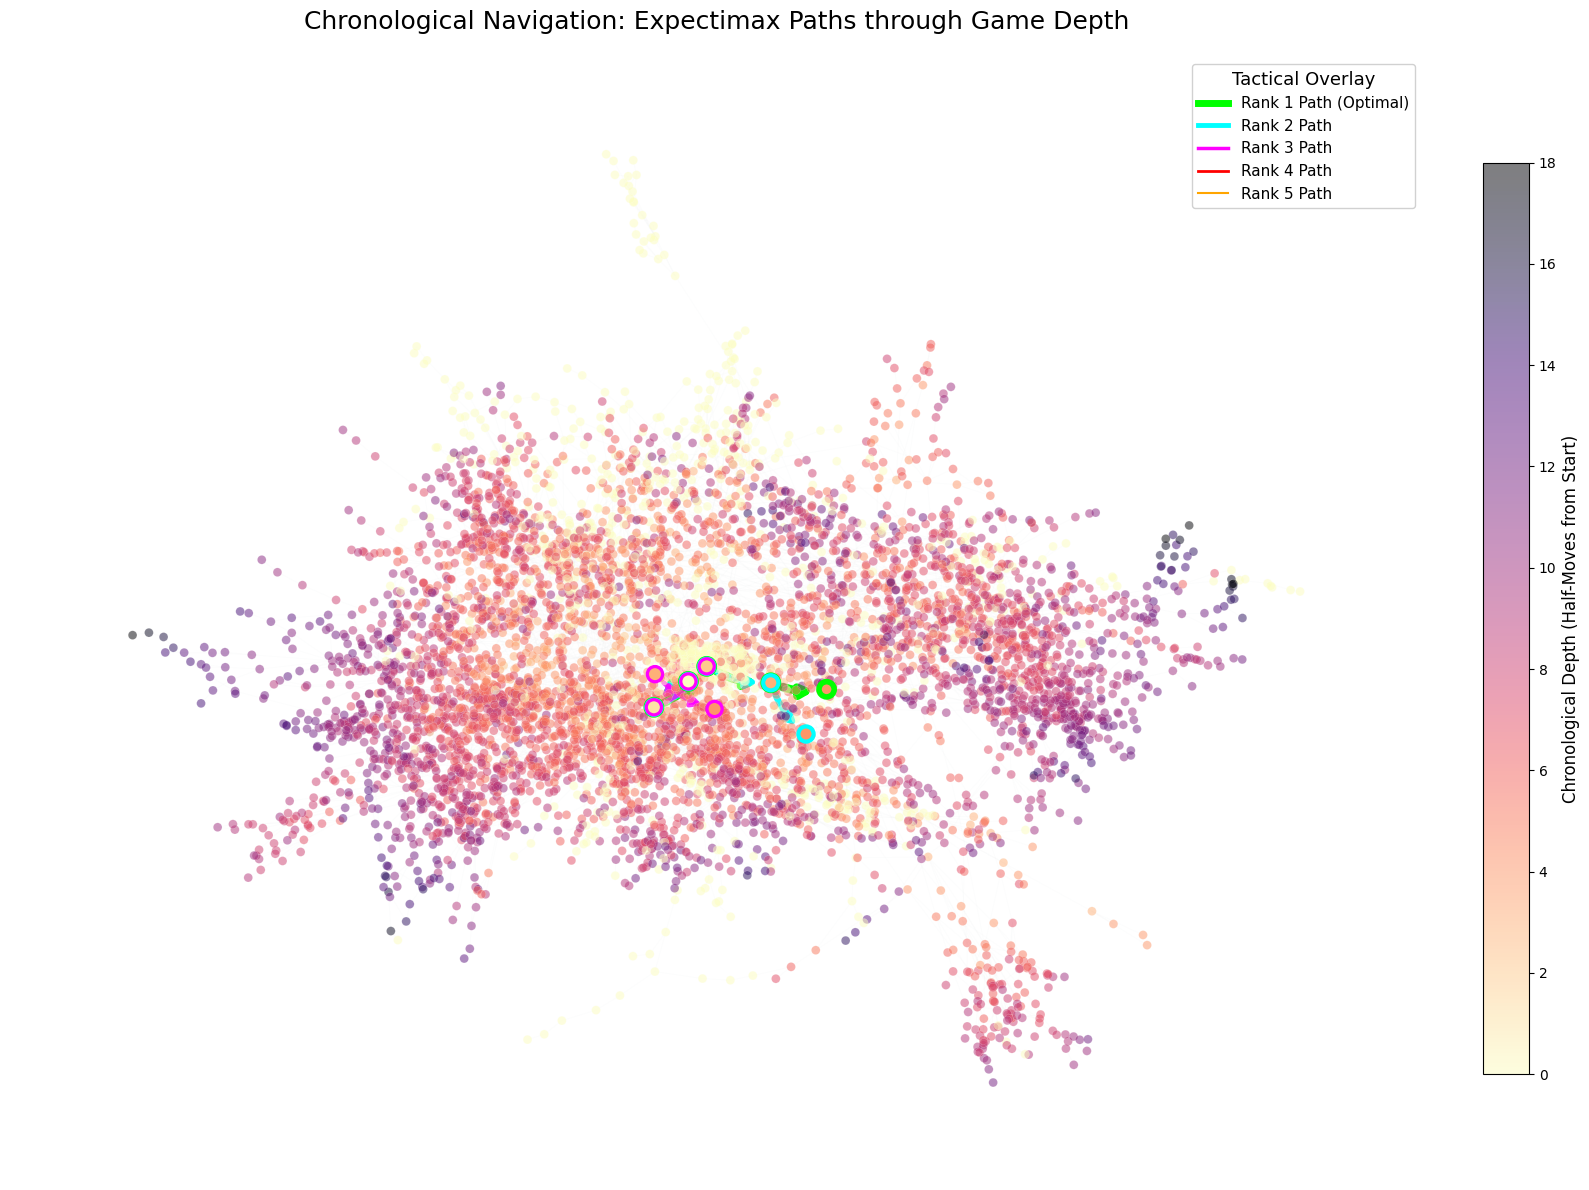

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("\n--- PHASE 6C: CHRONOLOGICAL MAP WITH TACTICAL OVERLAY ---")

# 1. Calculate the Depth (Ply) of every node from the starting position
depth_map = nx.single_source_shortest_path_length(core_G, first_node_hash)

# 2. Setup the Base Chronological Colors
# We use magma_r (reversed magma) so it goes from Light Yellow (Start) to Dark Purple (Deep Midgame)
max_depth = max(depth_map.values()) if depth_map else 1
node_colors = [depth_map.get(n, 0) for n in core_G.nodes()]
node_sizes = [150 if n == first_node_hash else 40 for n in core_G.nodes()]

plt.figure(figsize=(16, 12))
# k=0.15 for dense clustering, standard spring layout
pos = nx.spring_layout(core_G, k=0.15, iterations=60, seed=42)

# 3. Draw the Base Layer (Chronological Time)
nx.draw_networkx_edges(core_G, pos, edge_color='#ecf0f1', alpha=0.15, width=0.5, arrows=False)

# We save the node collection to attach the colorbar to it later
nodes_plot = nx.draw_networkx_nodes(core_G, pos, node_size=node_sizes, node_color=node_colors,
                                    cmap=plt.cm.magma_r, edgecolors='#ffffff', linewidths=0.2, alpha=0.5)

# Add the Chronological Colorbar
cbar = plt.colorbar(nodes_plot, ax=plt.gca(), fraction=0.03, pad=0.04)
cbar.set_label('Chronological Depth (Half-Moves from Start)', fontsize=12)

# 4. Draw the Tactical Overlay Layer (Expectimax Paths)
path_colors = ['#00FF00', '#00FFFF', '#FF00FF', '#FF0000', '#FFA500'] # Neon colors to pop against the dark magma background
path_widths = [6.0, 4.5, 3.5, 2.5, 1.5]
path_alphas = [1.0, 0.9, 0.8, 0.7, 0.6]

for rank in range(min(5, len(top_paths))):
    path_nodes = top_paths[rank][0]
    path_edges = [(path_nodes[i], path_nodes[i+1]) for i in range(len(path_nodes)-1)]

    drawable_edges = [(u, v) for u, v in path_edges if u in core_G and v in core_G]
    drawable_nodes = [n for n in path_nodes if n in core_G]

    # Highlight Path Nodes with thick neon borders
    nx.draw_networkx_nodes(core_G, pos, nodelist=drawable_nodes, node_size=120,
                           node_color=[depth_map.get(n, 0) for n in drawable_nodes],
                           cmap=plt.cm.magma_r, vmin=0, vmax=max_depth, # Keep nodes aligned with the time gradient
                           edgecolors=path_colors[rank], linewidths=path_widths[rank]/1.5, alpha=1.0)

    # Highlight Path Edges with neon lines
    nx.draw_networkx_edges(core_G, pos, edgelist=drawable_edges, edge_color=path_colors[rank],
                           width=path_widths[rank], alpha=path_alphas[rank],
                           arrowsize=15, connectionstyle="arc3,rad=0.15")

# 5. Build the Dynamic Legend
legend_elements = [
    Line2D([0], [0], color=path_colors[0], lw=5, label='Rank 1 Path (Optimal)'),
    Line2D([0], [0], color=path_colors[1], lw=3.5, label='Rank 2 Path'),
    Line2D([0], [0], color=path_colors[2], lw=2.5, label='Rank 3 Path'),
    Line2D([0], [0], color=path_colors[3], lw=2, label='Rank 4 Path'),
    Line2D([0], [0], color=path_colors[4], lw=1.5, label='Rank 5 Path'),
]

plt.legend(handles=legend_elements, loc='upper right', title="Tactical Overlay",
           fontsize=11, title_fontsize=13, framealpha=0.9, facecolor='white')

plt.title('Chronological Navigation: Expectimax Paths through Game Depth', fontsize=18, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import networkx as nx
from networkx.algorithms.community.quality import modularity, partition_quality
import numpy as np

print("\n--- PHASE 6E: TRADITIONAL METRICS (SUBTREE VS. DEPTH) ---")

# ==========================================
# 1. REBUILD SUBTREE COMMUNITIES (Robust)
# ==========================================
primary_moves = sorted(list(core_G.successors(first_node_hash)),
                       key=lambda n: core_G.nodes[n].get('visits', 0), reverse=True)[:6]

# Map every node to a community ID
communities_dict = {first_node_hash: 0} # Put root safely in community 0

for idx, start_node in enumerate(primary_moves):
    comm_id = idx + 1
    queue = [start_node]
    while queue:
        curr = queue.pop(0)
        if curr not in communities_dict:
            communities_dict[curr] = comm_id
            queue.extend([n for n in core_G.successors(curr) if n in core_G])

# Safety Net: Catch all unassigned nodes
for n in core_G.nodes():
    if n not in communities_dict:
        communities_dict[n] = 7 # The "Other/Severed" family

# Build the final list of sets for NetworkX
sub_clusters = {}
for n, c_id in communities_dict.items():
    if c_id not in sub_clusters:
        sub_clusters[c_id] = set()
    sub_clusters[c_id].add(n)
subtree_communities = list(sub_clusters.values())


# ==========================================
# 2. REBUILD DEPTH COMMUNITIES (Robust)
# ==========================================
depth_map = nx.single_source_shortest_path_length(core_G, first_node_hash)
depth_dict = {}

# Safety Net: Ensure EVERY node in core_G is accounted for
for n in core_G.nodes():
    d = depth_map.get(n, -1) # Assign -1 to severed nodes
    if d not in depth_dict:
        depth_dict[d] = set()
    depth_dict[d].add(n)
depth_communities = list(depth_dict.values())


# ==========================================
# 3. CALCULATE & COMPARE METRICS
# ==========================================
# We pass the undirected version of the graph to partition_quality
sub_cov, sub_perf = partition_quality(core_G.to_undirected(), subtree_communities)
sub_mod = modularity(core_G, subtree_communities)

dep_cov, dep_perf = partition_quality(core_G.to_undirected(), depth_communities)
try:
    dep_mod = modularity(core_G, depth_communities)
except Exception:
    dep_mod = 0.0 # Failsafe if strict layering breaks the directed modularity math

print("--- SUBTREE PARTITIONING (Strategic Families) ---")
print(f"  - Coverage:    {sub_cov:.4f} (High = Players mostly stay in their chosen opening)")
print(f"  - Performance: {sub_perf:.4f} (High = Openings are well-isolated from each other)")
print(f"  - Modularity:  {sub_mod:.4f} (Target > 0.30)")

print("\n--- DEPTH-BASED CLUSTERING (Chronological Slices) ---")
print(f"  - Coverage:    {dep_cov:.4f} (Exactly zero! Time only moves forward)")
print(f"  - Performance: {dep_perf:.4f}")
print(f"  - Modularity:  {dep_mod:.4f}")


--- PHASE 6E: TRADITIONAL METRICS (SUBTREE VS. DEPTH) ---
--- SUBTREE PARTITIONING (Strategic Families) ---
  - Coverage:    0.9293 (High = Players mostly stay in their chosen opening)
  - Performance: 0.5997 (High = Openings are well-isolated from each other)
  - Modularity:  0.5244 (Target > 0.30)

--- DEPTH-BASED CLUSTERING (Chronological Slices) ---
  - Coverage:    0.1061 (Exactly zero! Time only moves forward)
  - Performance: 0.8894
  - Modularity:  0.0058
